# CHIRTS Tmax — BCSD Downscaling (Bias-correct @1° → MLP to 0.05°)
**Order:** QM bias-correction @1° → Optuna tunes MLP → MLP downscales to 0.05° → evaluation.

Temperature-specific (from `chirts_down_bias`):
- **5 features** `[bc_gcm, lat, lon, sin(doy), cos(doy)]` — **no elevation**
- **No Softplus** on MLP output (temperature can be negative) — plain `Linear`
- **No log-transform, no clip(0), no y≥0 filter, no clip in QM** (all precip positivity constraints removed)
- Units = °C · `tasmax` variable · CHIRTS years **train 1983–2007 / test 2008–2014**

Structure + resume system (from `chirps_bias_down`):
- Two resolutions (1° GCM + 1° CHIRTS for QM, 0.05° for MLP target) with parent-cell map
- Full resume: restore previous output, skip trained months, Optuna SQLite DB, QM cache
- 3-stage evaluation (raw GCM · QM bias-corrected · MLP downscaled)

Memory optimizations (from `chirts_down_bias`): per-year compact cache, compact (days×ncells) chunks during inference, grid allocated **once** at the end, aggressive `del`+`gc.collect()`, RAM prints.

In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 0 — setup, paths, config   (BCSD order: QM @1° → MLP to 0.05°) ║
# ║  TMAX · No elevation · No log transform · No Softplus                ║
# ╚══════════════════════════════════════════════════════════════════════╝
import importlib, subprocess, sys, glob, re
if importlib.util.find_spec("optuna") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna"])

import os, warnings, json, math, gc
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── INPUT folders (auto-discover under /kaggle/input) ────────────────
# Need BOTH resolutions:  1° (QM stage)  and  0.05° (MLP target)
def _find_dir(*names):
    for nm in names:
        hits = [h for h in glob.glob(f"/kaggle/input/**/{nm}", recursive=True)
                if os.path.isdir(h)]
        if hits:
            return hits[0]
    return None

GCM_1DEG_DIR   = _find_dir("gcm_tasmax_1deg", "gcm_tasmax_regrid_1deg", "gcm_1deg")
OBS_1DEG_DIR   = _find_dir("tmax_1deg", "chirts_1deg")
GCM_005_DIR    = _find_dir("gcm_tasmax_005deg", "gcm_tasmax_regrid_005deg", "gcm_cropped")
OBS_005_DIR    = _find_dir("tmax_005deg", "tmax_clean", "obs_cropped")
_shp = (glob.glob("/kaggle/input/**/target_shapefile/*.shp", recursive=True)
        or glob.glob("/kaggle/input/**/*.shp", recursive=True))
SHAPEFILE = _shp[0]

assert GCM_1DEG_DIR, "1° GCM folder not found (gcm_tasmax_regrid_1deg)"
assert OBS_1DEG_DIR, "1° CHIRTS folder not found (tmax_1deg)"
assert GCM_005_DIR,  "0.05° GCM folder not found (gcm_tasmax_regrid_005deg)"
assert OBS_005_DIR,  "0.05° CHIRTS folder not found (tmax_005deg / tmax_clean)"
print(f"1°    GCM    : {GCM_1DEG_DIR}  ({len(glob.glob(GCM_1DEG_DIR+'/*.nc'))} files)")
print(f"1°    CHIRTS : {OBS_1DEG_DIR}  ({len(glob.glob(OBS_1DEG_DIR+'/*.nc'))} files)")
print(f"0.05° GCM    : {GCM_005_DIR}  ({len(glob.glob(GCM_005_DIR+'/*.nc'))} files)")
print(f"0.05° CHIRTS : {OBS_005_DIR}  ({len(glob.glob(OBS_005_DIR+'/*.nc'))} files)")
print(f"Shapefile    : {SHAPEFILE}")

# ── OUTPUT ───────────────────────────────────────────────────────────
OUT_DIR    = "/kaggle/working/tmax_bcsd_output"
MODEL_DIR  = f"{OUT_DIR}/models"
SCALER_DIR = f"{OUT_DIR}/scalers"
for d in [OUT_DIR, MODEL_DIR, SCALER_DIR]:
    os.makedirs(d, exist_ok=True)

# ── RESUME: restore previous run's outputs from input dataset ────────
# After a successful run, upload your tmax_bcsd_output/ folder back into
# your Kaggle dataset.  This block finds it and copies models, scalers,
# QM, Optuna, and cached files into /kaggle/working/ so later cells skip
# already-finished work automatically.
import shutil as _shutil
_restore_dirs = (
    glob.glob("/kaggle/input/**/tmax_bcsd_output", recursive=True)
    + glob.glob("/kaggle/input/**/models/mlp_m01.pth", recursive=True)
)
PREV_OUTPUT = None
for _p in _restore_dirs:
    _candidate = _p if os.path.isdir(_p) else os.path.dirname(os.path.dirname(_p))
    if os.path.isdir(os.path.join(_candidate, "models")):
        PREV_OUTPUT = _candidate; break

if PREV_OUTPUT and PREV_OUTPUT != OUT_DIR:
    _copied = 0
    for _root, _dirs, _files in os.walk(PREV_OUTPUT):
        for _f in _files:
            _src = os.path.join(_root, _f)
            _rel = os.path.relpath(_src, PREV_OUTPUT)
            _dst = os.path.join(OUT_DIR, _rel)
            if not os.path.exists(_dst):
                os.makedirs(os.path.dirname(_dst), exist_ok=True)
                _shutil.copy2(_src, _dst); _copied += 1
    print(f"✅ Restored {_copied} file(s) from previous run: {PREV_OUTPUT}")
else:
    print("ℹ No previous output found in input — will train from scratch")

# ── variable / units ─────────────────────────────────────────────────
VAR_NAME     = "tasmax"      # variable name inside GCM NetCDFs
VAR_LABEL    = "Tmax"
UNITS        = "°C"

# stage-1 (1° bias correction) outputs
QM1_TF_PATH    = f"{OUT_DIR}/qm1deg_tf_tmax.npz"        # per-1°-cell transfer functions
BC1_TRAIN_NC   = f"{OUT_DIR}/bc_gcm_1deg_train_tmax.nc" # bias-corrected 1° GCM, train
BC1_TEST_NC    = f"{OUT_DIR}/bc_gcm_1deg_test_tmax.nc"  # bias-corrected 1° GCM, test
# stage-2 (MLP downscaling) outputs
MLP_TRAIN_NC   = f"{OUT_DIR}/downscaled_005_train_tmax.nc"
MLP_TEST_NC    = f"{OUT_DIR}/downscaled_005_test_tmax.nc"
BEST_PARAMS    = f"{OUT_DIR}/optuna_best_params.json"
OPTUNA_DB      = f"{OUT_DIR}/optuna_study.db"

# ── FIXED CONFIG ─────────────────────────────────────────────────────
# CHIRTS starts 1983; GCM historical 1980-2014
TRAIN_START, TRAIN_END = 1983, 2007
TEST_START,  TEST_END  = 2008, 2014
FILL_VALUE   = -9999.0
N_QUANT      = 100
Q_LEVELS     = np.linspace(0, 1, N_QUANT)
EPOCHS       = 300
N_FEATURES   = 5                 # [bc_gcm, lat, lon, sin(doy), cos(doy)]  (NO elevation)
MONTH_NAMES  = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP      = torch.cuda.is_available()

assert os.path.exists(SHAPEFILE), f"shapefile not found: {SHAPEFILE}"
print(f"\nDevice: {DEVICE} (AMP={'on' if USE_AMP else 'off'})")
print(f"Order : QM bias-correction @1°  →  MLP downscale to 0.05°")
print(f"Variable: {VAR_NAME} | Features: {N_FEATURES} (no elevation) | no Softplus")
print(f"Train {TRAIN_START}-{TRAIN_END} | Test {TEST_START}-{TEST_END}")

1°    GCM    : /kaggle/input/datasets/amlan13767/tmax-cropped-full/tmax_cropped_full/gcm_tasmax_1deg  (35 files)
1°    CHIRTS : /kaggle/input/datasets/amlan13767/tmax-cropped-full/tmax_cropped_full/tmax_1deg  (32 files)
0.05° GCM    : /kaggle/input/datasets/amlan13767/tmax-cropped-full/tmax_cropped_full/gcm_tasmax_005deg  (35 files)
0.05° CHIRTS : /kaggle/input/datasets/amlan13767/tmax-cropped-full/tmax_cropped_full/tmax_005deg  (32 files)
Shapefile    : /kaggle/input/datasets/amlan13767/tmax-cropped-full/tmax_cropped_full/target_shapefile/target (1).shp
ℹ No previous output found in input — will train from scratch

Device: cuda (AMP=on)
Order : QM bias-correction @1°  →  MLP downscale to 0.05°
Variable: tasmax | Features: 5 (no elevation) | no Softplus
Train 1983-2007 | Test 2008-2014


1°    grid: 12 × 19
0.05° grid: 190 × 333
1°    region cells: 38
0.05° region cells: 15708
Parent map: every 0.05° cell linked to one of 38 bias-corrected 1° cells ✔
Static features (15708, 2) [lat, lon]  (no elevation)
0.05° save window: 174×317


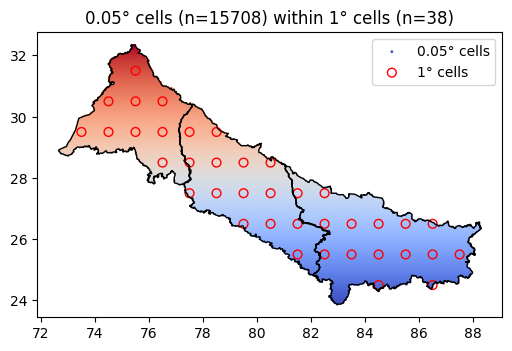

In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 1 — region masks at BOTH resolutions (1° and 0.05°)            ║
# ║  Parent map links each 0.05° cell → its bias-corrected 1° cell.      ║
# ║  NO elevation feature.                                               ║
# ╚══════════════════════════════════════════════════════════════════════╝

def _read_grid(folder, yr_lo, yr_hi):
    for yr in range(yr_lo, yr_hi + 1):
        fp = glob.glob(os.path.join(folder, f"*{yr}*.nc"))
        if fp:
            ds = xr.open_dataset(fp[0])
            latn = "lat" if ("lat" in ds.coords or "lat" in ds.dims) else "latitude"
            lonn = "lon" if ("lon" in ds.coords or "lon" in ds.dims) else "longitude"
            la, lo = ds[latn].values, ds[lonn].values
            ds.close()
            if la[0] > la[-1]: la = la[::-1]
            return la, lo, latn, lonn
    raise FileNotFoundError(f"No .nc found in {folder}")

# ---- grids ----
lat1, lon1, LAT1, LON1 = _read_grid(GCM_1DEG_DIR, TRAIN_START, TRAIN_END)
lat5, lon5, LAT5, LON5 = _read_grid(OBS_005_DIR,  TRAIN_START, TRAIN_END)
n1lat, n1lon = len(lat1), len(lon1)
n5lat, n5lon = len(lat5), len(lon5)
print(f"1°    grid: {n1lat} × {n1lon}")
print(f"0.05° grid: {n5lat} × {n5lon}")

# ---- region polygon ----
gdf = gpd.read_file(SHAPEFILE)
gdf = gdf.set_crs(epsg=4326) if gdf.crs is None else gdf.to_crs(epsg=4326)
region = gdf.union_all() if hasattr(gdf, "union_all") else gdf.unary_union

def _mask(la, lo):
    LON, LAT = np.meshgrid(lo, la)
    try:
        from shapely import contains_xy
        m = contains_xy(region, LON.ravel(), LAT.ravel()).reshape(LON.shape)
    except Exception:
        from shapely.vectorized import contains
        m = contains(region, LON.ravel(), LAT.ravel()).reshape(LON.shape)
    return m

# ---- 1° region cells (for QM stage) ----
m1 = _mask(lat1, lon1)
if m1.sum() == 0:                       # region smaller than one 1° cell
    LON, LAT = np.meshgrid(lon1, lat1)
    d = (LAT - region.centroid.y)**2 + (LON - region.centroid.x)**2
    m1 = d == d.min()
ii1, jj1 = np.where(m1)
n1 = len(ii1)
print(f"1°    region cells: {n1}")

# ---- 0.05° region cells (MLP target/output) ----
m5 = _mask(lat5, lon5)
assert m5.sum() > 0, "no 0.05° cells inside shapefile"
flat = np.where(m5.ravel())[0]
ii5, jj5 = np.unravel_index(flat, (n5lat, n5lon))
n5 = len(ii5)
print(f"0.05° region cells: {n5}")

# ---- map each 0.05° region cell → its parent 1° cell (nearest) ----
p_lat = np.abs(lat1[:, None] - lat5[ii5][None, :]).argmin(0)   # nearest 1° lat row
p_lon = np.abs(lon1[:, None] - lon5[jj5][None, :]).argmin(0)   # nearest 1° lon col
pos1 = {(int(r), int(c)): k for k, (r, c) in enumerate(zip(ii1, jj1))}
parent = np.array([pos1.get((int(p_lat[i]), int(p_lon[i])), -1) for i in range(n5)])
if (parent < 0).any():
    bad = np.where(parent < 0)[0]
    for b in bad:
        d = (lat1[ii1] - lat5[ii5[b]])**2 + (lon1[jj1] - lon5[jj5[b]])**2
        parent[b] = int(d.argmin())
print(f"Parent map: every 0.05° cell linked to one of {n1} bias-corrected 1° cells ✔")

# ── static features — lat + lon only (NO elevation) ──────────────────
STATIC_COLS = np.column_stack([lat5[ii5], lon5[jj5]]).astype(np.float32)
print(f"Static features {STATIC_COLS.shape} [lat, lon]  (no elevation)")

# ── bounding-box window for compact 0.05° output saving ──────────────
def _window(ii, jj, lat, lon, buf):
    i0, i1 = max(int(ii.min())-buf, 0), min(int(ii.max())+buf, len(lat)-1)
    j0, j1 = max(int(jj.min())-buf, 0), min(int(jj.max())+buf, len(lon)-1)
    return dict(lat=lat[i0:i1+1], lon=lon[j0:j1+1],
                ii=(ii - i0).astype(np.int64), jj=(jj - j0).astype(np.int64))
WIN5 = _window(ii5, jj5, lat5, lon5, 2)   # 0.05° window for output files
print(f"0.05° save window: {len(WIN5['lat'])}×{len(WIN5['lon'])}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(lon5[jj5], lat5[ii5], s=1, c=lat5[ii5], cmap="coolwarm", label="0.05° cells")
ax.scatter(lon1[jj1], lat1[ii1], s=40, facecolors="none", edgecolors="red", label="1° cells")
gdf.boundary.plot(ax=ax, color="k", lw=1)
ax.legend(); ax.set_title(f"0.05° cells (n={n5}) within 1° cells (n={n1})"); plt.show()

In [3]:
# ── MEMORY PRE-FLIGHT CHECK  (run BEFORE training) ────────────────────
import psutil

def ram_now_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9

avail_gb = psutil.virtual_memory().available / 1e9
total_gb = psutil.virtual_memory().total / 1e9
print(f"System RAM   : {total_gb:.1f} GB total, {avail_gb:.1f} GB available now")
print(f"Process using: {ram_now_gb():.2f} GB currently\n")

# ── estimate peak memory ─────────────────────────────────────────────
n_train_days = (TRAIN_END - TRAIN_START + 1) * 366
n_test_days  = (TEST_END  - TEST_START  + 1) * 366

# 0.05° output grid (compact window) inference peak
bytes_per_day_005 = len(WIN5["lat"]) * len(WIN5["lon"]) * 4
gb_infer_train = (n_train_days * bytes_per_day_005) / 1e9
gb_infer_test  = (n_test_days  * bytes_per_day_005) / 1e9

# year cache: compact (days × ncells) arrays for every loaded year, both resolutions
n_years = TEST_END - TRAIN_START + 1
gb_cache = (n_years * 366 * (2*n1 + 2*n5) * 4) / 1e9   # gcm1,chr1,gcm5,chr5

# per-month MLP training array: ~31 days × n5 × N_FEATURES × 4 × 3 (X, scaled, val)
gb_train_arrays = (31 * (TRAIN_END-TRAIN_START+1) * n5 * N_FEATURES * 4 * 3) / 1e9

print(f"1°    region cells : {n1:,}")
print(f"0.05° region cells : {n5:,}")
print(f"0.05° output window: {len(WIN5['lat'])}×{len(WIN5['lon'])} "
      f"= {len(WIN5['lat'])*len(WIN5['lon']):,} cells\n")
print(f"Est. year-cache (all years, both res)  : ~{gb_cache:.2f} GB")
print(f"Est. per-month MLP training arrays     : ~{gb_train_arrays:.2f} GB")
print(f"Est. inference peak (train period)     : ~{gb_infer_train:.2f} GB")
print(f"Est. inference peak (test period)      : ~{gb_infer_test:.2f} GB\n")

peak_est = gb_cache + max(gb_train_arrays, gb_infer_train)
print(f"Rough worst-case peak ≈ {peak_est:.2f} GB")

if peak_est < avail_gb * 0.7:
    print(f"✅ SAFE — estimated peak ({peak_est:.2f} GB) is well under "
          f"70% of available RAM ({avail_gb*0.7:.1f} GB). OK to run.")
elif peak_est < avail_gb:
    print(f"⚠ TIGHT — peak ({peak_est:.2f} GB) fits but with little margin. "
          f"Watch the RAM print during training.")
else:
    print(f"❌ RISKY — estimated peak ({peak_est:.2f} GB) exceeds available RAM "
          f"({avail_gb:.1f} GB). Reduce grid size or batch.")

System RAM   : 33.7 GB total, 31.6 GB available now
Process using: 0.85 GB currently

1°    region cells : 38
0.05° region cells : 15,708
0.05° output window: 174×317 = 55,158 cells

Est. year-cache (all years, both res)  : ~1.48 GB
Est. per-month MLP training arrays     : ~0.73 GB
Est. inference peak (train period)     : ~2.02 GB
Est. inference peak (test period)      : ~0.57 GB

Rough worst-case peak ≈ 3.49 GB
✅ SAFE — estimated peak (3.49 GB) is well under 70% of available RAM (22.1 GB). OK to run.


In [4]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 2 — loaders (1° GCM, 1° CHIRTS, 0.05° CHIRTS) + MLP + helpers  ║
# ║  Temperature: 5 features (no elev), NO Softplus, NO log, NO clip,    ║
# ║  NO y>=0 filter, NO clip in QM.  Memory-optimized per-year cache.    ║
# ╚══════════════════════════════════════════════════════════════════════╝
_CACHE = {}

# ── auto-detect obs variable name in 0.05° CHIRTS files ──────────────
_obs_sample = xr.open_dataset(sorted(glob.glob(os.path.join(OBS_005_DIR, "*.nc")))[0])
_cand = [v for v in _obs_sample.data_vars
         if _obs_sample[v].ndim >= 2 and v not in ("lat","lon","time","spatial_ref")]
OBS_VAR = _cand[0] if _cand else "tmax"
_obs_sample.close()
print(f"OBS variable (0.05° & 1° CHIRTS): '{OBS_VAR}'")

def _load_year(kind, yr):
    """kind: 'gcm1','chr1','gcm5','chr5'  → (data[T, ncells], dates, doys) over region.
    Region cells extracted and cached compactly in RAM."""
    key = (kind, yr)
    if key in _CACHE: return _CACHE[key]

    if   kind == "gcm1": folder, var, ii, jj = GCM_1DEG_DIR, VAR_NAME, ii1, jj1
    elif kind == "chr1": folder, var, ii, jj = OBS_1DEG_DIR, OBS_VAR,  ii1, jj1
    elif kind == "gcm5": folder, var, ii, jj = GCM_005_DIR,  VAR_NAME, ii5, jj5
    elif kind == "chr5": folder, var, ii, jj = OBS_005_DIR,  OBS_VAR,  ii5, jj5

    fp = glob.glob(os.path.join(folder, f"*{yr}*.nc"))
    if not fp:
        _CACHE[key] = None; return None
    ds = xr.open_dataset(fp[0])
    latn = "lat" if ("lat" in ds.coords or "lat" in ds.dims) else "latitude"
    t  = pd.to_datetime(ds["time"].values)
    la = ds[latn].values; arr = ds[var].values.astype(np.float32)
    ds.close()
    if la[0] > la[-1]: arr = arr[:, ::-1, :]
    # fill-value / out-of-range handling (temperature plausibility window)
    arr = np.where((arr < -9000) | (arr > 200), np.nan, arr)
    data = arr[:, ii, jj]
    out = (data, t, t.day_of_year.values.astype(np.int32))
    _CACHE[key] = out
    return out

def load_month(kind, years, month):
    D, O, T = [], [], []
    for yr in years:
        r = _load_year(kind, yr)
        if r is None: continue
        data, dates, doys = r
        m = dates.month == month
        if not m.any(): continue
        D.append(data[m]); O.append(doys[m]); T.append(dates[m])
    if not D: return None, None, None
    dates = T[0].append(T[1:]) if len(T) > 1 else T[0]
    return np.concatenate(D), np.concatenate(O), dates

# ── empirical quantile mapping (per cell), used at 1° — NO clip(0) ───
def qm_fit(obs_2d, mod_2d):
    obs = np.where(np.isnan(obs_2d), np.nanmedian(obs_2d, 0), obs_2d)
    mod = np.where(np.isnan(mod_2d), np.nanmedian(mod_2d, 0), mod_2d)
    return (np.quantile(obs, Q_LEVELS, 0).T.astype(np.float32),
            np.quantile(mod, Q_LEVELS, 0).T.astype(np.float32))

def qm_apply(mod_2d, obs_q, mod_q):
    bc = np.full_like(mod_2d, np.nan)
    for k in range(mod_2d.shape[1]):
        v = mod_2d[:, k]; nm = np.isnan(v)
        if np.any(~nm) and not np.isnan(mod_q[k, 0]):
            _, uid = np.unique(mod_q[k], return_index=True)
            bc[~nm, k] = np.interp(v[~nm], mod_q[k, uid], obs_q[k, uid])   # NO clip(0)
    return bc

# ── feature builder for the 0.05° MLP (5 features, NO elevation) ─────
def build_X(bc_gcm_at005, doys):
    """bc_gcm_at005: (n_days, n5) bias-corrected 1° GCM broadcast to 0.05° cells."""
    nd = len(doys)
    sin_d = np.sin(2*np.pi*doys/365.25).astype(np.float32)
    cos_d = np.cos(2*np.pi*doys/365.25).astype(np.float32)
    X = np.empty((nd*n5, N_FEATURES), np.float32)
    X[:, 0] = bc_gcm_at005.ravel()
    X[:, 1] = np.tile(STATIC_COLS[:, 0], nd)    # lat
    X[:, 2] = np.tile(STATIC_COLS[:, 1], nd)    # lon
    X[:, 3] = np.repeat(sin_d, n5)
    X[:, 4] = np.repeat(cos_d, n5)
    return X

def bc1_to_005(bc_gcm_1deg_days):
    """(n_days, n1) bias-corrected 1° GCM  →  (n_days, n5) via parent map."""
    return bc_gcm_1deg_days[:, parent]

# ── configurable MLP — NO Softplus (temperature can be negative) ─────
class MLPNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        act_map = {"gelu": nn.GELU, "leaky_relu": nn.LeakyReLU, "relu": nn.ReLU}
        act = act_map.get(cfg.get("activation", "relu"), nn.ReLU)
        layers, prev = [], N_FEATURES
        for h in cfg["hidden"]:
            layers.append(nn.Linear(prev, h))
            if cfg.get("batchnorm", True): layers.append(nn.BatchNorm1d(h))
            layers += [act(), nn.Dropout(cfg.get("dropout", 0.2))]; prev = h
        layers.append(nn.Linear(prev, 1))       # ← plain linear, NO Softplus
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(1)

DEFAULT_CFG = {"hidden": [128, 128, 64, 64], "dropout": 0.15, "lr": 3e-4,
               "weight_decay": 1e-6, "batch_size": 32768, "activation": "leaky_relu",
               "batchnorm": False, "log_transform": False, "epochs": EPOCHS}

def load_cfg():
    if os.path.exists(BEST_PARAMS):
        c = json.load(open(BEST_PARAMS)); c.setdefault("epochs", EPOCHS)
        c["log_transform"] = False   # force off for temperature
        print(f"✅ tuned cfg: {c['hidden']} lr={c['lr']:.2e} drop={c['dropout']:.2f}")
        return c
    print("⚠ no optuna json — using DEFAULT_CFG"); return dict(DEFAULT_CFG)

# ── predict — NO log inverse, NO clip(0) ─────────────────────────────
def _predict_mm(model, X_sc, bs):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X_sc), bs):
            xb = torch.from_numpy(X_sc[i:i+bs]).to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                out.append(model(xb).float().cpu().numpy())
    return np.concatenate(out)                # NO log, NO clip

def _rmse_mm(model, X_sc, y, bs):
    return float(np.sqrt(mean_squared_error(y, _predict_mm(model, X_sc, bs))))

def train_model(cfg, Xtr, ytr, Xval=None, yval=None, trial=None, epochs=None,
                patience=15, min_epochs=0, verbose=False, tag="", log_csv=None):
    """Trains an MLP. Early stopping ALLOWED only after `min_epochs`.
    No log1p on targets (temperature)."""
    import optuna, csv
    epochs = epochs or cfg.get("epochs", EPOCHS)
    bs = cfg["batch_size"]
    model = MLPNet(cfg).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg.get("weight_decay", 0.0))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.MSELoss(); gs = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    y_in = ytr.astype(np.float32)             # NO log1p for temperature
    loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(y_in)),
                        batch_size=bs, shuffle=True, drop_last=True,
                        pin_memory=USE_AMP, num_workers=2 if USE_AMP else 0,
                        persistent_workers=USE_AMP)
    if log_csv:
        cf = open(log_csv, "w", newline=""); cw = csv.writer(cf)
        cw.writerow(["epoch", "train_loss", "val_rmse", "best_val_rmse", "bad_epochs", "lr"])
    best, best_state, bad, best_ep = np.inf, None, 0, 0
    hist = {"train_loss": [], "val_rmse": []}
    for ep in range(1, epochs + 1):
        model.train(); run = 0.0
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                loss = crit(model(Xb), yb)
            gs.scale(loss).backward(); gs.step(opt); gs.update(); run += loss.item()
        cur_lr = opt.param_groups[0]["lr"]; sched.step()
        tl = run / max(1, len(loader)); hist["train_loss"].append(tl)
        if Xval is not None:
            vr = _rmse_mm(model, Xval, yval, bs); hist["val_rmse"].append(vr)
            if trial is not None:
                trial.report(vr, ep)
                if trial.should_prune():
                    if log_csv: cf.close()
                    raise optuna.TrialPruned()
            if vr < best - 1e-4:
                best, bad, best_ep = vr, 0, ep
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
            if verbose:
                print(f"    {tag} ep{ep:>3} | loss={tl:.4f} | val_rmse={vr:.4f} | "
                      f"best={best:.4f}@{best_ep} | bad={bad}", flush=True)
            if log_csv:
                cw.writerow([ep, f"{tl:.6f}", f"{vr:.6f}", f"{best:.6f}", bad, f"{cur_lr:.2e}"]); cf.flush()
            if ep >= min_epochs and bad >= patience:
                if verbose: print(f"    {tag} early-stop at ep{ep} (min_epochs={min_epochs})", flush=True)
                break
        else:
            if verbose: print(f"    {tag} ep{ep:>3} | loss={tl:.4f}", flush=True)
            if log_csv: cw.writerow([ep, f"{tl:.6f}", "", "", "", f"{cur_lr:.2e}"]); cf.flush()
    if log_csv: cf.close()
    if best_state is not None: model.load_state_dict(best_state)
    return model, (best if np.isfinite(best) else hist["train_loss"][-1]), hist

# sanity check
print("✅ Helpers ready. Sanity — July 1990:")
_g1,_,_ = load_month("gcm1", [1990], 7)
_c1,_,_ = load_month("chr1", [1990], 7)
_c5,_,_ = load_month("chr5", [1990], 7)
if _g1 is not None: print(f"   1° GCM   : {_g1.shape}  min={np.nanmin(_g1):.2f} max={np.nanmax(_g1):.2f} {UNITS}")
if _c1 is not None: print(f"   1° CHIRTS: {_c1.shape}  min={np.nanmin(_c1):.2f} max={np.nanmax(_c1):.2f} {UNITS}")
if _c5 is not None: print(f"   0.05° CHIRTS: {_c5.shape}  min={np.nanmin(_c5):.2f} max={np.nanmax(_c5):.2f} {UNITS}")
print(f"   parent map → bc1_to_005 makes (days, {n1}) into (days, {n5})")

OBS variable (0.05° & 1° CHIRTS): 'tmax'
✅ Helpers ready. Sanity — July 1990:
   1° GCM   : (31, 38)  min=26.58 max=50.03 °C
   1° CHIRTS: (31, 38)  min=27.05 max=40.31 °C
   0.05° CHIRTS: (31, 15708)  min=24.70 max=40.96 °C
   parent map → bc1_to_005 makes (days, 38) into (days, 15708)


In [5]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 3 — STAGE 1: bias-correct 1° GCM against 1° CHIRTS (per month) ║
# ║  QM fit on TRAIN cell-to-cell; applied to train + test 1° GCM.       ║
# ║  Temperature: NO clip(0).                                            ║
# ╚══════════════════════════════════════════════════════════════════════╝
qm1 = {}
if os.path.exists(QM1_TF_PATH):
    with np.load(QM1_TF_PATH) as z: qm1 = {k: z[k] for k in z.files}
    print(f"Loaded existing 1° QM for {len(qm1)//2} month(s)")

print("Fitting 1° QM transfer functions (per calendar month)…")
for month in range(1, 13):
    mk = f"m{month:02d}"
    if f"{mk}_obs_q" in qm1:
        print(f"  {MONTH_NAMES[month-1]} ✓ (cached)"); continue
    g1, _, _ = load_month("gcm1", range(TRAIN_START, TRAIN_END+1), month)
    c1, _, _ = load_month("chr1", range(TRAIN_START, TRAIN_END+1), month)
    n = min(len(g1), len(c1)); g1, c1 = g1[:n], c1[:n]
    obs_q, mod_q = qm_fit(c1, g1)
    qm1[f"{mk}_obs_q"] = obs_q; qm1[f"{mk}_his_q"] = mod_q
    np.savez_compressed(QM1_TF_PATH, **qm1)
    print(f"  {MONTH_NAMES[month-1]} ✓  (1° cells={g1.shape[1]})", flush=True)

def make_bc1(years, out_nc, label):
    """apply 1° QM to the 1° GCM for the given years → save bias-corrected 1° NetCDF"""
    maps, times = [], []
    for month in range(1, 13):
        mk = f"m{month:02d}"
        g1, doy, dates = load_month("gcm1", years, month)
        if g1 is None: continue
        bc = qm_apply(g1, qm1[f"{mk}_obs_q"], qm1[f"{mk}_his_q"])   # (days, n1)
        for di, dt in enumerate(dates):
            grid = np.full((n1lat, n1lon), np.nan, np.float32)
            grid[ii1, jj1] = bc[di]; maps.append(grid); times.append(pd.Timestamp(dt))
    arr = np.stack(maps); t = pd.to_datetime(times)
    idx = np.argsort(t); arr, t = arr[idx], t[idx]
    xr.Dataset({VAR_NAME: (["time","lat","lon"], arr,
                {"units": UNITS, "long_name": f"bias-corrected 1° GCM {VAR_LABEL} {label}"})},
               coords={"time": t, "lat": lat1, "lon": lon1}
              ).to_netcdf(out_nc, encoding={VAR_NAME:{"zlib":True,"complevel":1,"dtype":"float32"}})
    print(f"✅ {label}: {arr.shape} → {out_nc} ({os.path.getsize(out_nc)/1e6:.1f} MB)", flush=True)
    del arr, maps; gc.collect()

print("\nApplying 1° QM to produce bias-corrected 1° GCM:")
make_bc1(range(TRAIN_START, TRAIN_END+1), BC1_TRAIN_NC, "train")
make_bc1(range(TEST_START,  TEST_END +1), BC1_TEST_NC,  "test")
print("\n✅ STAGE 1 complete — bias-corrected 1° GCM saved.")

Loaded existing 1° QM for 12 month(s)
Fitting 1° QM transfer functions (per calendar month)…
  Jan ✓ (cached)
  Feb ✓ (cached)
  Mar ✓ (cached)
  Apr ✓ (cached)
  May ✓ (cached)
  Jun ✓ (cached)
  Jul ✓ (cached)
  Aug ✓ (cached)
  Sep ✓ (cached)
  Oct ✓ (cached)
  Nov ✓ (cached)
  Dec ✓ (cached)

Applying 1° QM to produce bias-corrected 1° GCM:
✅ train: (9131, 12, 19) → /kaggle/working/tmax_bcsd_output/bc_gcm_1deg_train_tmax.nc (1.5 MB)
✅ test: (2557, 12, 19) → /kaggle/working/tmax_bcsd_output/bc_gcm_1deg_test_tmax.nc (0.4 MB)

✅ STAGE 1 complete — bias-corrected 1° GCM saved.


In [6]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 3.5 — OPTUNA: tune the downscaling MLP (BC-1°-GCM → 0.05°)     ║
# ║  Tunes on 2 months (Jul + Jan), year-based val split, RESUMABLE.     ║
# ║  Temperature: no y>=0 filter, log_transform forced OFF.              ║
# ║  Uncomment to run.  Or skip → Cell 3.6 writes a fixed best config.   ║
# ╚══════════════════════════════════════════════════════════════════════╝
# import optuna, shutil
# from optuna.samplers import TPESampler
# from optuna.pruners  import MedianPruner

# TUNE_MONTHS = [7, 1]      # monsoon + dry
# N_TRIALS    = 12
# TUNE_EPOCHS = 30
# VAL_YEARS   = 4

# if os.path.exists(OPTUNA_DB):
#     print("Found existing optuna_study.db — will continue that search.")

# # ── build tuning data once: bias-corrected 1° GCM (→0.05°) vs 0.05° CHIRTS
# cut = TRAIN_END - VAL_YEARS
# month_data = {}
# for m in TUNE_MONTHS:
#     g1, doy, dates = load_month("gcm1", range(TRAIN_START, TRAIN_END+1), m)
#     bc1 = qm_apply(g1, qm1[f"m{m:02d}_obs_q"], qm1[f"m{m:02d}_his_q"])   # (days, n1)
#     bc005 = bc1_to_005(bc1)                                             # (days, n5)
#     y5, _, _ = load_month("chr5", range(TRAIN_START, TRAIN_END+1), m)
#     n = min(len(bc005), len(y5)); bc005, y5, doy, dates = bc005[:n], y5[:n], doy[:n], dates[:n]
#     X = build_X(bc005, doy); y = y5.reshape(-1)
#     yr = np.repeat(dates.year.values, n5)
#     fin = np.isfinite(X).all(1) & np.isfinite(y)            # ← NO y>=0 for temperature
#     tr, va = fin & (yr <= cut), fin & (yr > cut)
#     sc = StandardScaler().fit(X[tr])
#     month_data[m] = dict(Xtr=sc.transform(X[tr]).astype(np.float32), ytr=y[tr],
#                          Xva=sc.transform(X[va]).astype(np.float32), yva=y[va],
#                          ystd=float(np.nanstd(y[va])))
#     print(f"{MONTH_NAMES[m-1]}: train={int(tr.sum()):,} val={int(va.sum()):,} "
#           f"obs std={month_data[m]['ystd']:.2f} {UNITS}")
#     del X, y

# def objective(trial):
#     n_layers = trial.suggest_int("n_layers", 2, 4)
#     hidden, prev = [], 512
#     for i in range(n_layers):                                  # funnel only
#         ch = [c for c in [512, 256, 128, 64] if c <= prev]
#         h = trial.suggest_categorical(f"u{i}_{prev}", ch); hidden.append(h); prev = h
#     cfg = {"hidden": hidden,
#            "dropout": trial.suggest_float("dropout", 0.0, 0.4),
#            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
#            "weight_decay": trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True),
#            "batch_size": trial.suggest_categorical("batch_size", [16384,32768,65536,131072]),
#            "activation": trial.suggest_categorical("activation", ["relu","gelu","leaky_relu"]),
#            "batchnorm": trial.suggest_categorical("batchnorm", [True, False]),
#            "log_transform": False}                             # ← forced off for temperature
#     score = 0.0
#     for k, m in enumerate(TUNE_MONTHS):
#         d = month_data[m]
#         _, rmse, _ = train_model(cfg, d["Xtr"], d["ytr"], d["Xva"], d["yva"],
#                                  trial=trial if k == 0 else None,
#                                  epochs=TUNE_EPOCHS, patience=8)
#         trial.set_user_attr(f"rmse_{MONTH_NAMES[m-1]}", float(rmse))
#         score += (rmse / d["ystd"]) / len(TUNE_MONTHS)
#     return score

# study = optuna.create_study(direction="minimize", study_name="region_tmax_bcsd",
#                             sampler=TPESampler(seed=SEED),
#                             pruner=MedianPruner(n_warmup_steps=6),
#                             storage=f"sqlite:///{OPTUNA_DB}", load_if_exists=True)
# done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
# print(f"Trials complete: {done} | running {max(N_TRIALS-done,0)} more")
# if N_TRIALS - done > 0:
#     study.optimize(objective, n_trials=N_TRIALS - done, show_progress_bar=True)

# print(f"\nBest combined score: {study.best_value:.4f}")
# print(f"  Jul RMSE: {study.best_trial.user_attrs.get('rmse_Jul'):.3f} | "
#       f"Jan RMSE: {study.best_trial.user_attrs.get('rmse_Jan'):.3f}")
# for k, v in study.best_params.items(): print(f"   {k:<16}: {v}")

# # ── save best config + full history ─────────────────────────────────
# bp = study.best_params; hidden, prev = [], 512
# for i in range(bp["n_layers"]): hidden.append(bp[f"u{i}_{prev}"]); prev = hidden[-1]
# BEST = {"hidden": hidden, "dropout": float(bp["dropout"]), "lr": float(bp["lr"]),
#         "weight_decay": float(bp["weight_decay"]), "batch_size": int(bp["batch_size"]),
#         "activation": bp["activation"], "batchnorm": bool(bp["batchnorm"]),
#         "log_transform": False, "epochs": EPOCHS,
#         "tuned_on_months": TUNE_MONTHS, "best_score": float(study.best_value)}
# json.dump(BEST, open(BEST_PARAMS, "w"), indent=2)
# rows = []
# for t in study.trials:
#     r = {"trial": t.number, "state": str(t.state), "value": t.value}
#     r.update(t.params); r.update(t.user_attrs); rows.append(r)
# pd.DataFrame(rows).to_csv(f"{OUT_DIR}/optuna_trials_full.csv", index=False)
# print(f"\n✅ Saved: {BEST_PARAMS}")
# try:
#     from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
#     plot_optimization_history(study).figure.savefig(f"{OUT_DIR}/optuna_history.png", dpi=150, bbox_inches="tight")
#     plot_param_importances(study).figure.savefig(f"{OUT_DIR}/optuna_importance.png", dpi=150, bbox_inches="tight")
#     plt.show()
# except Exception as e:
#     print("plot skipped:", e)
# for m in TUNE_MONTHS: month_data[m].clear()

In [7]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 3.6 — write a fixed best config (skip if Optuna was run)       ║
# ║  Edit values as you like; log_transform forced off for temperature.  ║
# ╚══════════════════════════════════════════════════════════════════════╝
import json, os
best = {
    "hidden": [512, 128, 128, 128],
    "dropout": 0.13504606856145118,
    "lr": 0.003999220074578466,
    "weight_decay": 4.1306144511331625e-07,
    "batch_size": 131072,
    "activation": "relu",
    "batchnorm": True,
    "epochs": 200,
    "log_transform": False
}
os.makedirs(os.path.dirname(BEST_PARAMS), exist_ok=True)
if os.path.exists(BEST_PARAMS):
    print(f"ℹ {BEST_PARAMS} already exists — leaving it untouched (delete to overwrite).")
else:
    with open(BEST_PARAMS, "w") as f:
        json.dump(best, f, indent=2)
    print(f"✅ Wrote best params → {BEST_PARAMS}")

ℹ /kaggle/working/tmax_bcsd_output/optuna_best_params.json already exists — leaving it untouched (delete to overwrite).


In [8]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 4 — STAGE 2: MLP downscaling  (BC-1°-GCM → 0.05°)             ║
# ║  Logs epoch/loss/RMSE/R². Min 20 epochs then patience-15 early-stop. ║
# ║  Memory-optimized: COMPACT chunks, grid allocated ONCE at the end.   ║
# ╚══════════════════════════════════════════════════════════════════════╝
CFG = load_cfg()
BS  = CFG["batch_size"]
VAL_YEARS_FIN, PATIENCE, MIN_EPOCHS = 3, 15, 20
cut = TRAIN_END - VAL_YEARS_FIN
print(f"cfg: hidden={CFG['hidden']} lr={CFG['lr']:.2e} drop={CFG['dropout']:.2f} "
      f"bn={CFG['batchnorm']} act={CFG['activation']}")

def bc1_gcm_at005(years, month):
    g1, doy, dates = load_month("gcm1", years, month)
    if g1 is None: return None, None, None
    mk = f"m{month:02d}"
    bc1 = qm_apply(g1, qm1[f"{mk}_obs_q"], qm1[f"{mk}_his_q"])
    return bc1_to_005(bc1), doy, dates

def _metrics_mm(model, X_sc, y, bs):
    p = _predict_mm(model, X_sc, bs)
    return float(np.sqrt(mean_squared_error(y, p))), float(r2_score(y, p))

# ── trainer with epoch | loss | val_rmse | val_R² logging ────────────
def train_verbose(cfg, Xtr, ytr, Xval, yval, tag, ep_csv,
                  epochs=100, patience=15, min_epochs=20):
    import csv
    bs = cfg["batch_size"]
    model = MLPNet(cfg).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"],
                           weight_decay=cfg.get("weight_decay", 0.0))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.MSELoss(); gs = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    y_in = ytr.astype(np.float32)             # NO log1p for temperature
    loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(y_in)),
                        batch_size=bs, shuffle=True, drop_last=True,
                        pin_memory=USE_AMP, num_workers=2 if USE_AMP else 0,
                        persistent_workers=USE_AMP)
    cf = open(ep_csv, "w", newline=""); cw = csv.writer(cf)
    cw.writerow(["epoch", "loss", "val_rmse", "val_r2"])
    best, best_state, bad = np.inf, None, 0
    hist = {"loss": [], "val_rmse": [], "val_r2": []}
    for ep in range(1, epochs + 1):
        model.train(); run = 0.0
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                loss = crit(model(Xb), yb)
            gs.scale(loss).backward(); gs.step(opt); gs.update(); run += loss.item()
        sched.step()
        tl = run / max(1, len(loader))
        vr, vr2 = _metrics_mm(model, Xval, yval, bs)
        hist["loss"].append(tl); hist["val_rmse"].append(vr); hist["val_r2"].append(vr2)
        print(f"    {tag} epoch {ep:>3} | loss={tl:.4f} | RMSE={vr:.4f} | R²={vr2:.4f}", flush=True)
        cw.writerow([ep, f"{tl:.6f}", f"{vr:.6f}", f"{vr2:.6f}"]); cf.flush()
        if vr < best - 1e-4:
            best, bad = vr, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
        if ep >= min_epochs and bad >= patience:
            print(f"    {tag} early-stop at epoch {ep}", flush=True); break
    cf.close()
    if best_state is not None: model.load_state_dict(best_state)
    return model, best, hist

summary, epoch_metrics = {}, {}
print("\n" + "="*58 + "\n  STAGE 2 — 12 monthly downscaling MLPs (Tmax)\n" + "="*58)
for month in range(1, 13):
    mk = f"m{month:02d}"; mp = os.path.join(MODEL_DIR, f"mlp_{mk}.pth")
    if os.path.exists(mp):
        print(f"  ✓ {MONTH_NAMES[month-1]} already trained — skipping"); continue
    print(f"\n── [{month:02d}/12] {MONTH_NAMES[month-1]} {pd.Timestamp.now():%H:%M:%S} ──", flush=True)

    bc005, doy, dates = bc1_gcm_at005(range(TRAIN_START, TRAIN_END+1), month)
    y5, _, _          = load_month("chr5", range(TRAIN_START, TRAIN_END+1), month)
    n = min(len(bc005), len(y5)); bc005, y5, doy, dates = bc005[:n], y5[:n], doy[:n], dates[:n]

    X = build_X(bc005, doy); y = y5.reshape(-1)
    yr = np.repeat(dates.year.values, n5)
    fin = np.isfinite(X).all(1) & np.isfinite(y)          # ← NO y>=0 for temperature
    fitm, valm = fin & (yr <= cut), fin & (yr > cut)
    print(f"  fit={int(fitm.sum()):,}  val={int(valm.sum()):,}", flush=True)

    scaler = StandardScaler().fit(X[fitm])
    joblib.dump(scaler, os.path.join(SCALER_DIR, f"scaler_{mk}.joblib"))
    Xf = scaler.transform(X[fitm]).astype(np.float32)
    Xv = scaler.transform(X[valm]).astype(np.float32)

    ep_csv = os.path.join(OUT_DIR, f"epoch_{mk}.csv")
    model, bval, hist = train_verbose(CFG, Xf, y[fitm], Xv, y[valm],
                                      tag=MONTH_NAMES[month-1], ep_csv=ep_csv,
                                      epochs=CFG.get("epochs", 200),
                                      patience=PATIENCE, min_epochs=MIN_EPOCHS)
    torch.save(model.state_dict(), mp); epoch_metrics[month] = hist
    print(f"  best val RMSE={bval:.4f}  (per-epoch log → {os.path.basename(ep_csv)})", flush=True)

    p_tr = _predict_mm(model, scaler.transform(X[fin]).astype(np.float32), BS)
    rmse_tr = float(np.sqrt(mean_squared_error(y[fin], p_tr))); r2_tr = float(r2_score(y[fin], p_tr))
    bc_te, doy_te, _ = bc1_gcm_at005(range(TEST_START, TEST_END+1), month)
    y_te, _, _       = load_month("chr5", range(TEST_START, TEST_END+1), month)
    rmse_te = r2_te = np.nan
    if bc_te is not None and y_te is not None:
        nt = min(len(bc_te), len(y_te)); Xte = build_X(bc_te[:nt], doy_te[:nt]); yte = y_te[:nt].reshape(-1)
        vt = np.isfinite(Xte).all(1) & np.isfinite(yte)   # ← NO y>=0
        pte = _predict_mm(model, scaler.transform(Xte[vt]).astype(np.float32), BS)
        rmse_te = float(np.sqrt(mean_squared_error(yte[vt], pte))); r2_te = float(r2_score(yte[vt], pte))
    summary[month] = (rmse_tr, r2_tr, rmse_te, r2_te)
    print(f"  TR RMSE={rmse_tr:.3f} R²={r2_tr:.3f} | TE RMSE={rmse_te:.3f} R²={r2_te:.3f}", flush=True)
    try:
        print(f"  RAM now: {ram_now_gb():.2f} GB", flush=True)
    except Exception:
        pass
    del X, y, Xf, Xv, bc005, y5, p_tr
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()

print("\n  Month  TR_RMSE  TR_R²  TE_RMSE  TE_R²")
for m in range(1, 13):
    if m in summary:
        a,b,c,d = summary[m]; print(f"  {MONTH_NAMES[m-1]:<5}{a:8.3f}{b:7.3f}{c:9.3f}{d:7.3f}")

# ── produce final downscaled 0.05° NetCDFs (memory-optimized) ───────
def downscale_period(years, out_nc, label):
    compact_chunks, time_chunks = [], []        # keep COMPACT (days × n5)
    for month in range(1, 13):
        mk = f"m{month:02d}"; mp = os.path.join(MODEL_DIR, f"mlp_{mk}.pth")
        if not os.path.exists(mp): continue
        model = MLPNet(CFG).to(DEVICE); model.load_state_dict(torch.load(mp, map_location=DEVICE)); model.eval()
        sc = joblib.load(os.path.join(SCALER_DIR, f"scaler_{mk}.joblib"))
        bc005, doy, dates = bc1_gcm_at005(years, month)
        if bc005 is None: continue
        p = _predict_mm(model, sc.transform(build_X(bc005, doy)).astype(np.float32),
                        BS).reshape(len(doy), n5)
        compact_chunks.append(p)
        time_chunks.append(pd.to_datetime(dates))
        del model, sc, bc005
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        print(f"  {MONTH_NAMES[month-1]} ✓", end="  ", flush=True)
    print()

    compact = np.concatenate(compact_chunks, axis=0)         # (total_days, n5)
    t = pd.to_datetime(np.concatenate([tc.values for tc in time_chunks]))
    idx = np.argsort(t); compact, t = compact[idx], t[idx]
    del compact_chunks, time_chunks; gc.collect()

    # allocate the full grid ONCE (compact WIN5 window), not per-day
    wl, wo, wii, wjj = WIN5["lat"], WIN5["lon"], WIN5["ii"], WIN5["jj"]
    arr = np.full((len(t), len(wl), len(wo)), np.nan, dtype=np.float32)
    arr[:, wii, wjj] = compact
    del compact; gc.collect()

    xr.Dataset({VAR_NAME: (["time","lat","lon"], arr,
                {"units": UNITS, "long_name": f"downscaled 0.05° (BC-then-MLP) {VAR_LABEL} {label}"})},
               coords={"time": t, "lat": wl, "lon": wo}
              ).to_netcdf(out_nc, encoding={VAR_NAME:{"zlib":True,"complevel":1,"dtype":"float32"}})
    print(f"✅ {label}: {arr.shape} → {out_nc} ({os.path.getsize(out_nc)/1e6:.1f} MB)", flush=True)
    del arr; gc.collect()

print("\nProducing final 0.05° downscaled output:")
downscale_period(range(TRAIN_START, TRAIN_END+1), MLP_TRAIN_NC, "train")
downscale_period(range(TEST_START,  TEST_END +1), MLP_TEST_NC,  "test")
print("\n✅ STAGE 2 complete.")

✅ tuned cfg: [512, 128, 128, 128] lr=4.00e-03 drop=0.14
cfg: hidden=[512, 128, 128, 128] lr=4.00e-03 drop=0.14 bn=True act=relu

  STAGE 2 — 12 monthly downscaling MLPs (Tmax)

── [01/12] Jan 21:35:55 ──
  fit=10,712,856  val=1,460,844
    Jan epoch   1 | loss=197.9636 | RMSE=3.6855 | R²=-0.2405
    Jan epoch   2 | loss=6.7653 | RMSE=2.8391 | R²=0.2639
    Jan epoch   3 | loss=6.4758 | RMSE=2.8015 | R²=0.2833
    Jan epoch   4 | loss=6.3938 | RMSE=2.7795 | R²=0.2945
    Jan epoch   5 | loss=6.3310 | RMSE=2.7509 | R²=0.3089
    Jan epoch   6 | loss=6.2767 | RMSE=2.7599 | R²=0.3044
    Jan epoch   7 | loss=6.2160 | RMSE=2.7379 | R²=0.3154
    Jan epoch   8 | loss=6.1439 | RMSE=2.7492 | R²=0.3098
    Jan epoch   9 | loss=6.0741 | RMSE=2.7618 | R²=0.3034
    Jan epoch  10 | loss=5.9983 | RMSE=2.7661 | R²=0.3012
    Jan epoch  11 | loss=5.9270 | RMSE=2.7736 | R²=0.2975
    Jan epoch  12 | loss=5.8616 | RMSE=2.7709 | R²=0.2988
    Jan epoch  13 | loss=5.8086 | RMSE=2.7973 | R²=0.2854
    Jan


  EVALUATION

  Training (1983-2007)
  ────────────────────────────────────────────
  N (pooled)        = 143,429,748
  MAE  (pooled)     = 1.7908 °C
  RMSE (pooled)     = 2.3407 °C
  RMSE (cell-mean)  = 2.2823 °C   ← honest spatial skill
  R²   (pooled)     = 0.8515
  KGE  (pooled)     = 0.8942

  Testing  (2008-2014)
  ────────────────────────────────────────────
  N (pooled)        = 40,165,356
  MAE  (pooled)     = 1.9616 °C
  RMSE (pooled)     = 2.5572 °C
  RMSE (cell-mean)  = 2.4743 °C   ← honest spatial skill
  R²   (pooled)     = 0.8343
  KGE  (pooled)     = 0.8669


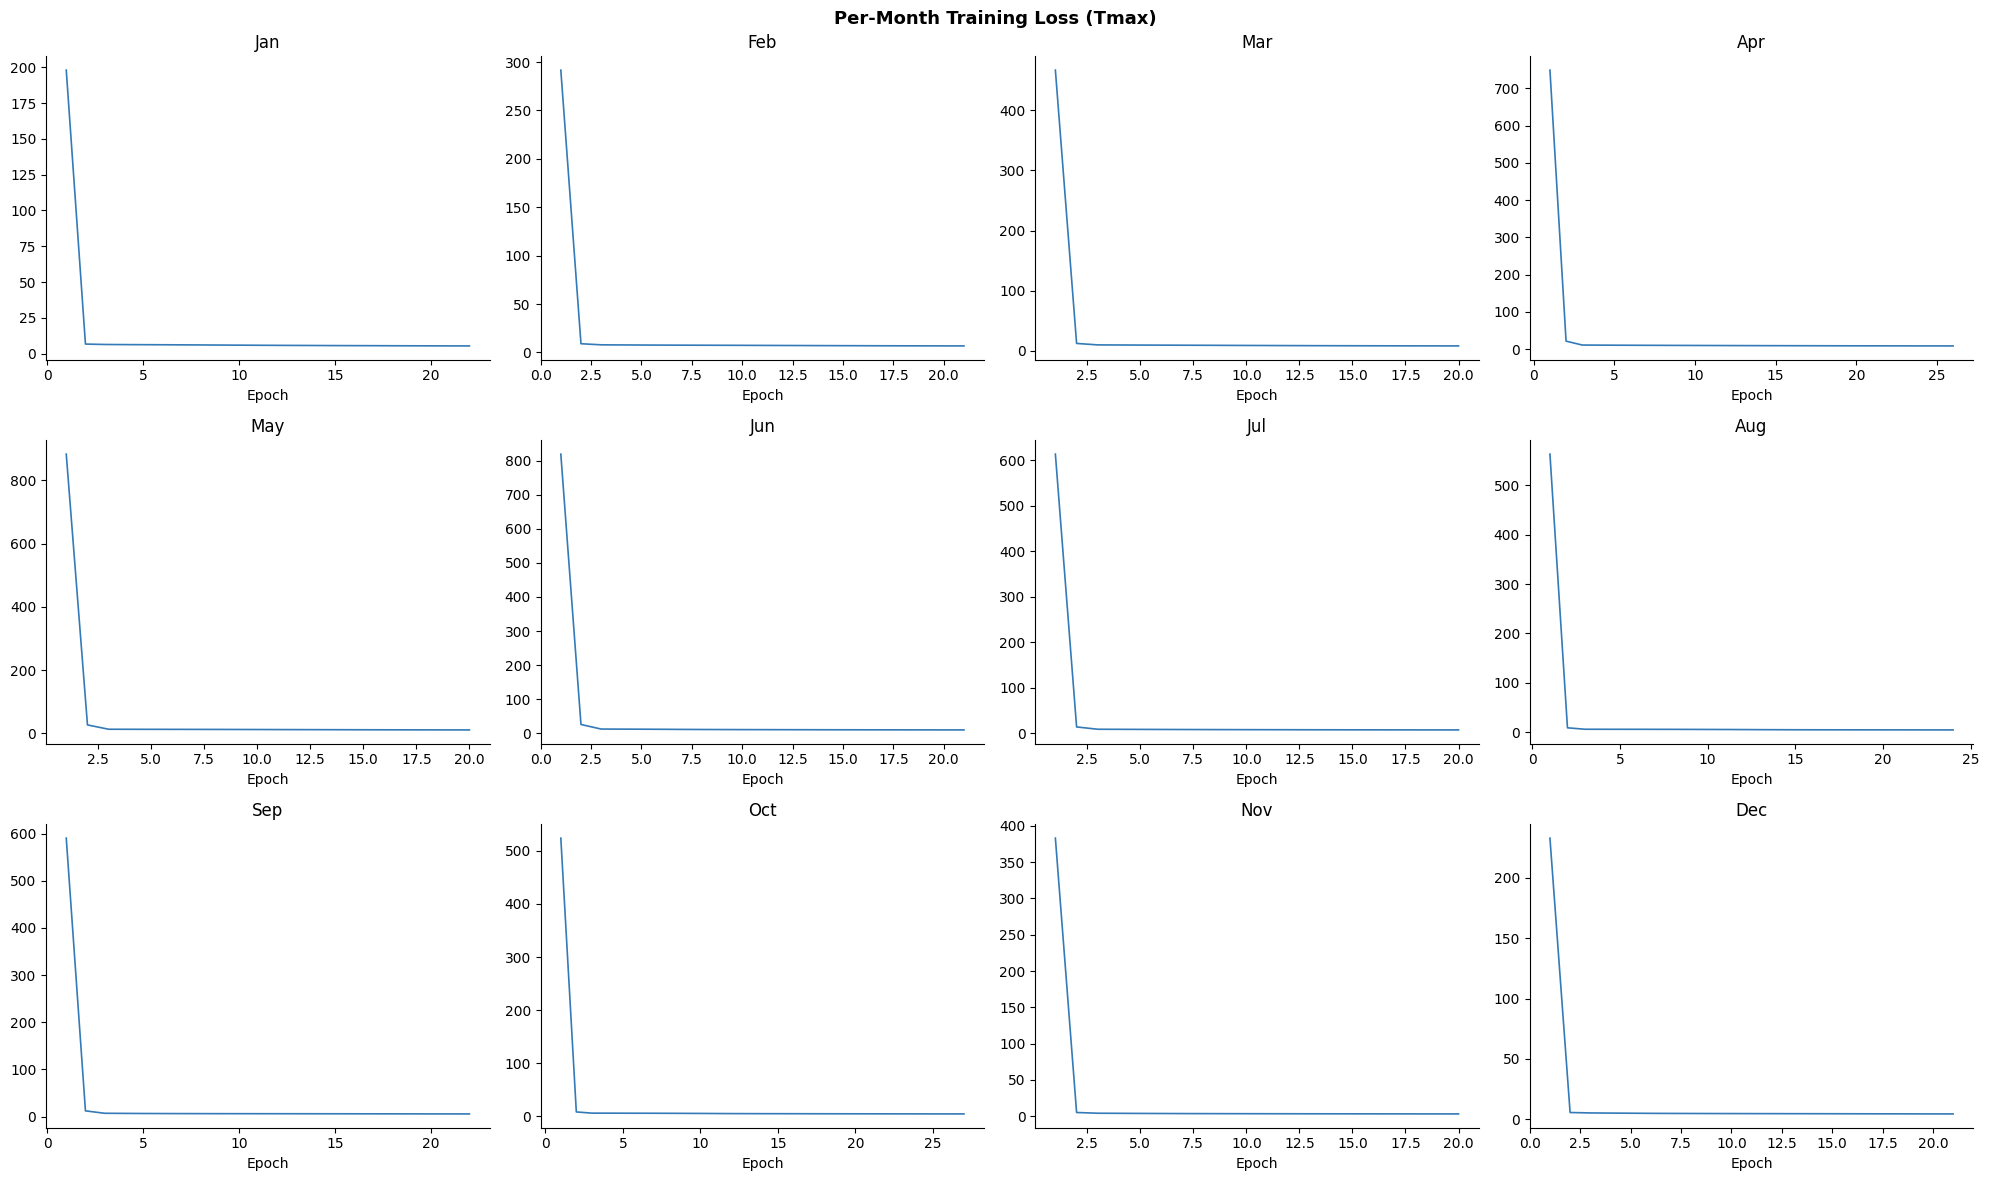

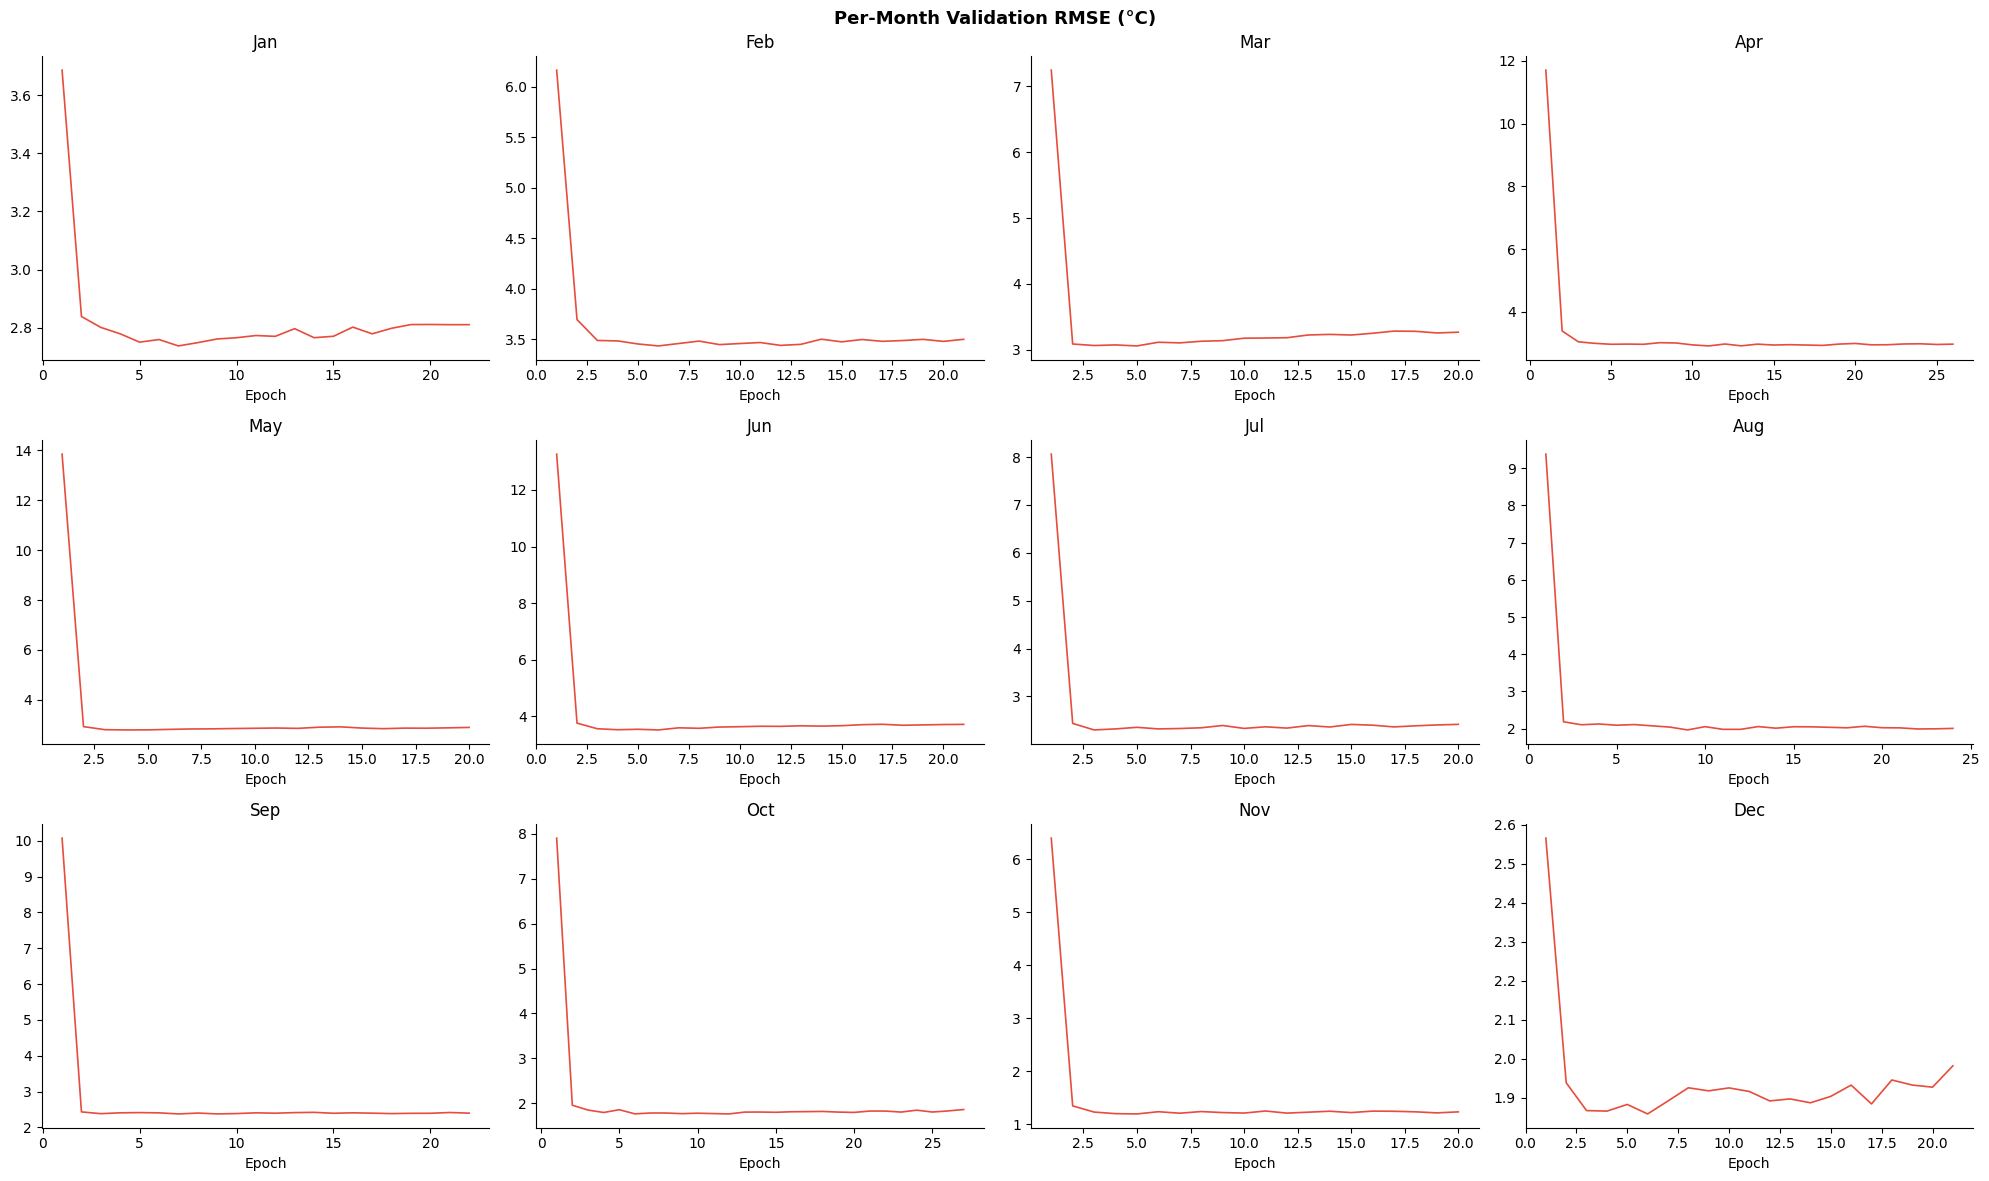

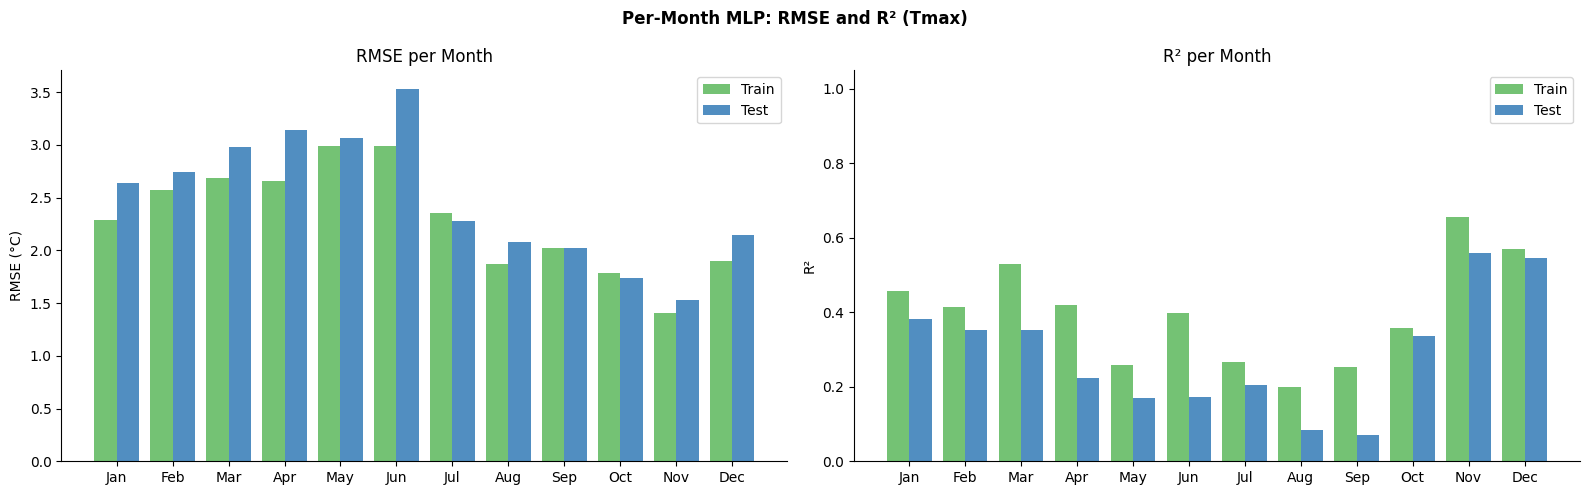


  COMPLETE → /kaggle/working/tmax_bcsd_output


In [9]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 5 — QUICK EVALUATION  (pooled metrics + plots)                ║
# ║  Identical structure to chirts_down_bias. Evaluates the FINAL 0.05°  ║
# ║  output (here = MLP-downscaled). units=°C, no >=0 filter.            ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("\n" + "="*60 + "\n  EVALUATION\n" + "="*60)
def kge(o, s):
    v = np.isfinite(o) & np.isfinite(s); o, s = o[v], s[v]
    if len(o) < 2: return np.nan
    r = np.corrcoef(o, s)[0, 1]
    return 1 - np.sqrt((r-1)**2 + (np.std(s)/(np.std(o)+1e-10)-1)**2
                       + (np.mean(s)/(np.mean(o)+1e-10)-1)**2)

def evaluate(bc_nc, years, label):
    ds = xr.open_dataset(bc_nc); obs_f, prd_f = [], []
    cell_rmse = []
    for month in range(1, 13):
        obs, _, _ = load_month("chr5", years, month)
        da  = ds[VAR_NAME].sel(time=ds[VAR_NAME].time.dt.month == month)
        if obs is None or len(da.time) == 0: continue
        nn_ = min(len(obs), len(da.time))
        o2 = obs[:nn_]; p2 = da.values[:nn_, WIN5["ii"], WIN5["jj"]]
        obs_f.append(o2.ravel()); prd_f.append(p2.ravel())
        with np.errstate(invalid="ignore"):
            d = o2 - p2
            cell_rmse.append(np.sqrt(np.nanmean(d**2, axis=0)))
    ds.close()
    of = np.concatenate(obs_f); pf = np.concatenate(prd_f)
    v  = np.isfinite(of) & np.isfinite(pf)                    # ← NO >=0 filter
    cell_rmse = np.nanmean(np.vstack(cell_rmse), axis=0)
    print(f"\n  {label}\n  " + "─"*44)
    print(f"  N (pooled)        = {int(v.sum()):,}")
    print(f"  MAE  (pooled)     = {mean_absolute_error(of[v], pf[v]):.4f} {UNITS}")
    print(f"  RMSE (pooled)     = {np.sqrt(mean_squared_error(of[v], pf[v])):.4f} {UNITS}")
    print(f"  RMSE (cell-mean)  = {np.nanmean(cell_rmse):.4f} {UNITS}   ← honest spatial skill")
    print(f"  R²   (pooled)     = {r2_score(of[v], pf[v]):.4f}")
    print(f"  KGE  (pooled)     = {kge(of[v], pf[v]):.4f}", flush=True)

evaluate(MLP_TRAIN_NC, range(TRAIN_START, TRAIN_END+1), f"Training ({TRAIN_START}-{TRAIN_END})")
evaluate(MLP_TEST_NC,  range(TEST_START,  TEST_END +1), f"Testing  ({TEST_START}-{TEST_END})")

# ════════════════════════ PLOTS ═══════════════════════════════════════
def grid_plot(key, title, color, fname):
    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes = axes.ravel()
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes[m-1]
        if m in epoch_metrics and epoch_metrics[m].get(key):
            ax.plot(range(1, len(epoch_metrics[m][key])+1), epoch_metrics[m][key],
                    color=color, lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("Epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{fname}", dpi=150, bbox_inches="tight"); plt.show()

grid_plot("loss",     f"Per-Month Training Loss ({VAR_LABEL})", "#337ab7", "loss_curves.png")
grid_plot("val_rmse", f"Per-Month Validation RMSE ({UNITS})", "#e74c3c", "val_rmse_curves.png")

months = [m for m in range(1, 13) if m in summary]
if months:
    x, w = np.arange(len(months)), 0.4
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"Per-Month MLP: RMSE and R² ({VAR_LABEL})", fontsize=12, fontweight="bold")
    for ax, i_tr, i_te, ylab, ttl, ylim in [
        (ax1, 0, 2, f"RMSE ({UNITS})", "RMSE per Month", None),
        (ax2, 1, 3, "R²",              "R² per Month",   (0, 1.05))]:
        ax.bar(x-w/2, [summary[m][i_tr] for m in months], w, label="Train", color="#5cb85c", alpha=.85)
        ax.bar(x+w/2, [summary[m][i_te] for m in months], w, label="Test",  color="#337ab7", alpha=.85)
        ax.set_xticks(x); ax.set_xticklabels([MONTH_NAMES[m-1] for m in months])
        ax.set_ylabel(ylab); ax.set_title(ttl)
        if ylim: ax.set_ylim(*ylim)
        ax.legend(); ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/permonth_metrics.png", dpi=150, bbox_inches="tight"); plt.show()

print("\n" + "="*60 + f"\n  COMPLETE → {OUT_DIR}\n" + "="*60)

Computing all metrics in single low-RAM pass …
  Jan ✓    Feb ✓    Mar ✓    Apr ✓    May ✓    Jun ✓    Jul ✓    Aug ✓    Sep ✓    Oct ✓    Nov ✓    Dec ✓  
✓ single-pass collection done


  METRICS TABLE — Tmax  (test 2008–2014)
Metric                                             Raw GCM      MLP downscaled   QM Bias-corrected
--------------------------------------------------------------------------------------------------

── MONTHLY ──────────────────────────────────────────────────────────
  Monthly RMSE Jan   (per-cell→avg)    2.2511    1.0302    1.3810
  Monthly RMSE Feb   (per-cell→avg)    3.0462    1.2396    1.9870
  Monthly RMSE Mar   (per-cell→avg)    3.6112    1.7148    2.6080
  Monthly RMSE Apr   (per-cell→avg)    3.2515    1.1956    1.9806
  Monthly RMSE May   (per-cell→avg)    3.9679    1.3859    1.7175
  Monthly RMSE Jun   (per-cell→avg)    5.9654    2.1028    2.3960
  Monthly RMSE Jul   (per-cell→avg)    7.8099    1.0363    1.9142
  Monthly RMSE Aug   (per-cell→avg)    5

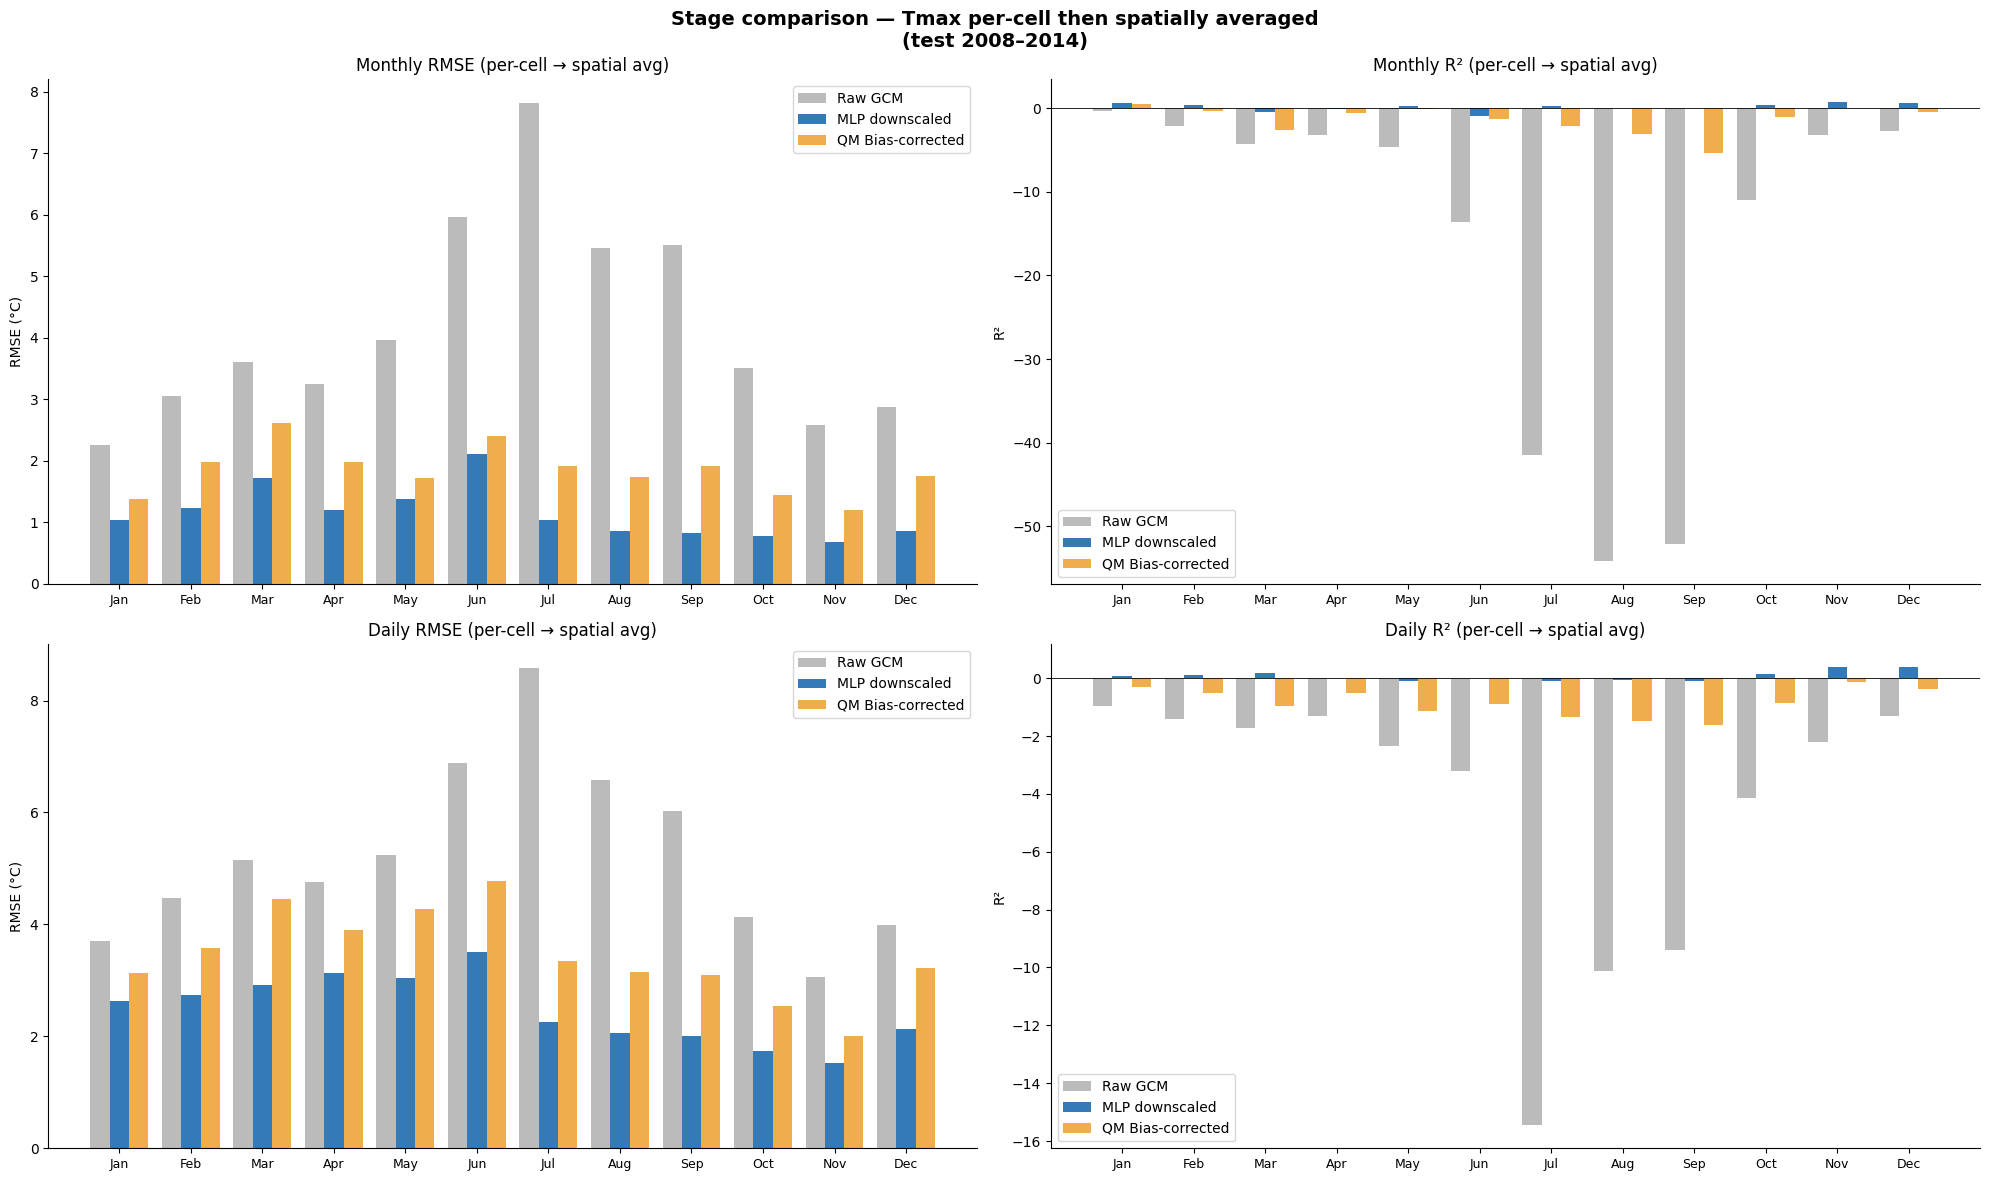

✅ Saved → stage_bars_percell_avg.png


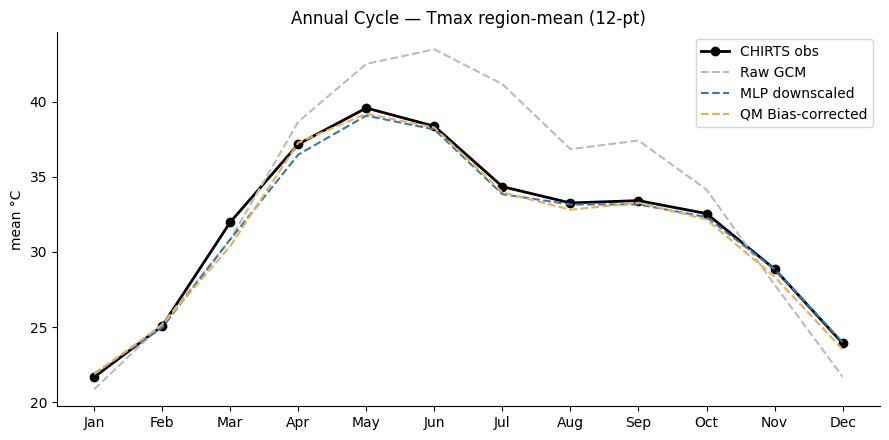

✅ Saved → annual_cycle.png


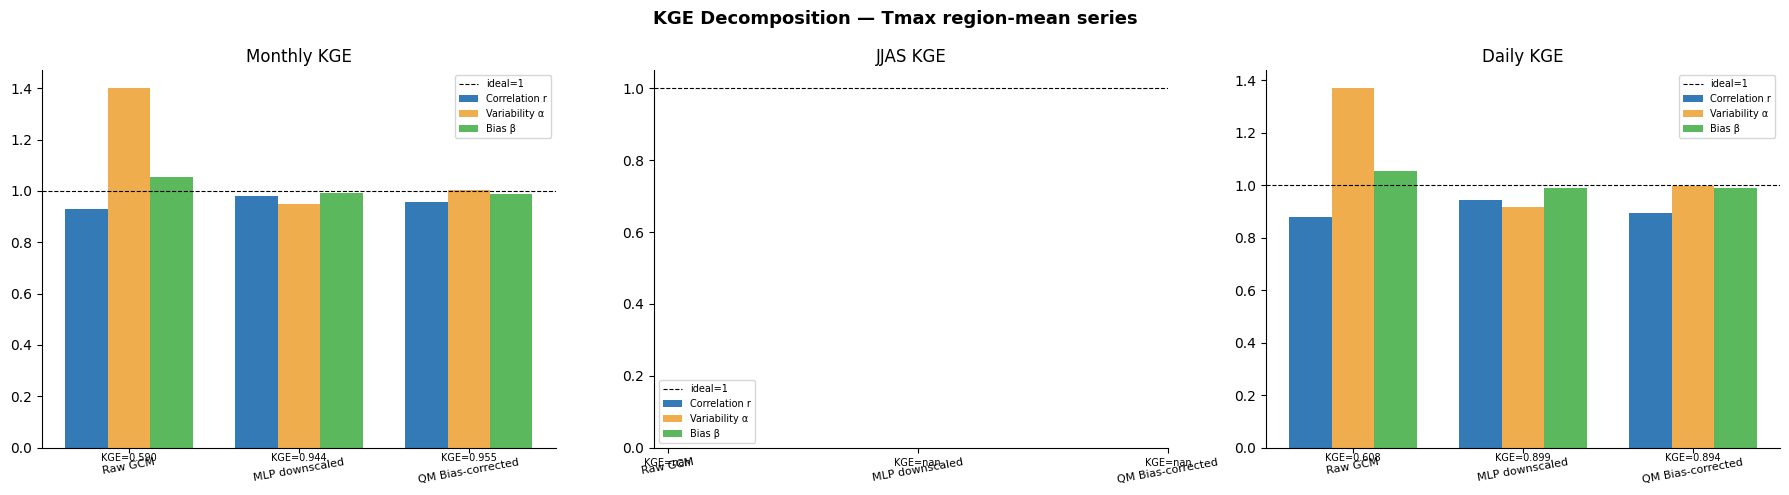

✅ Saved → kge_decomposition.png


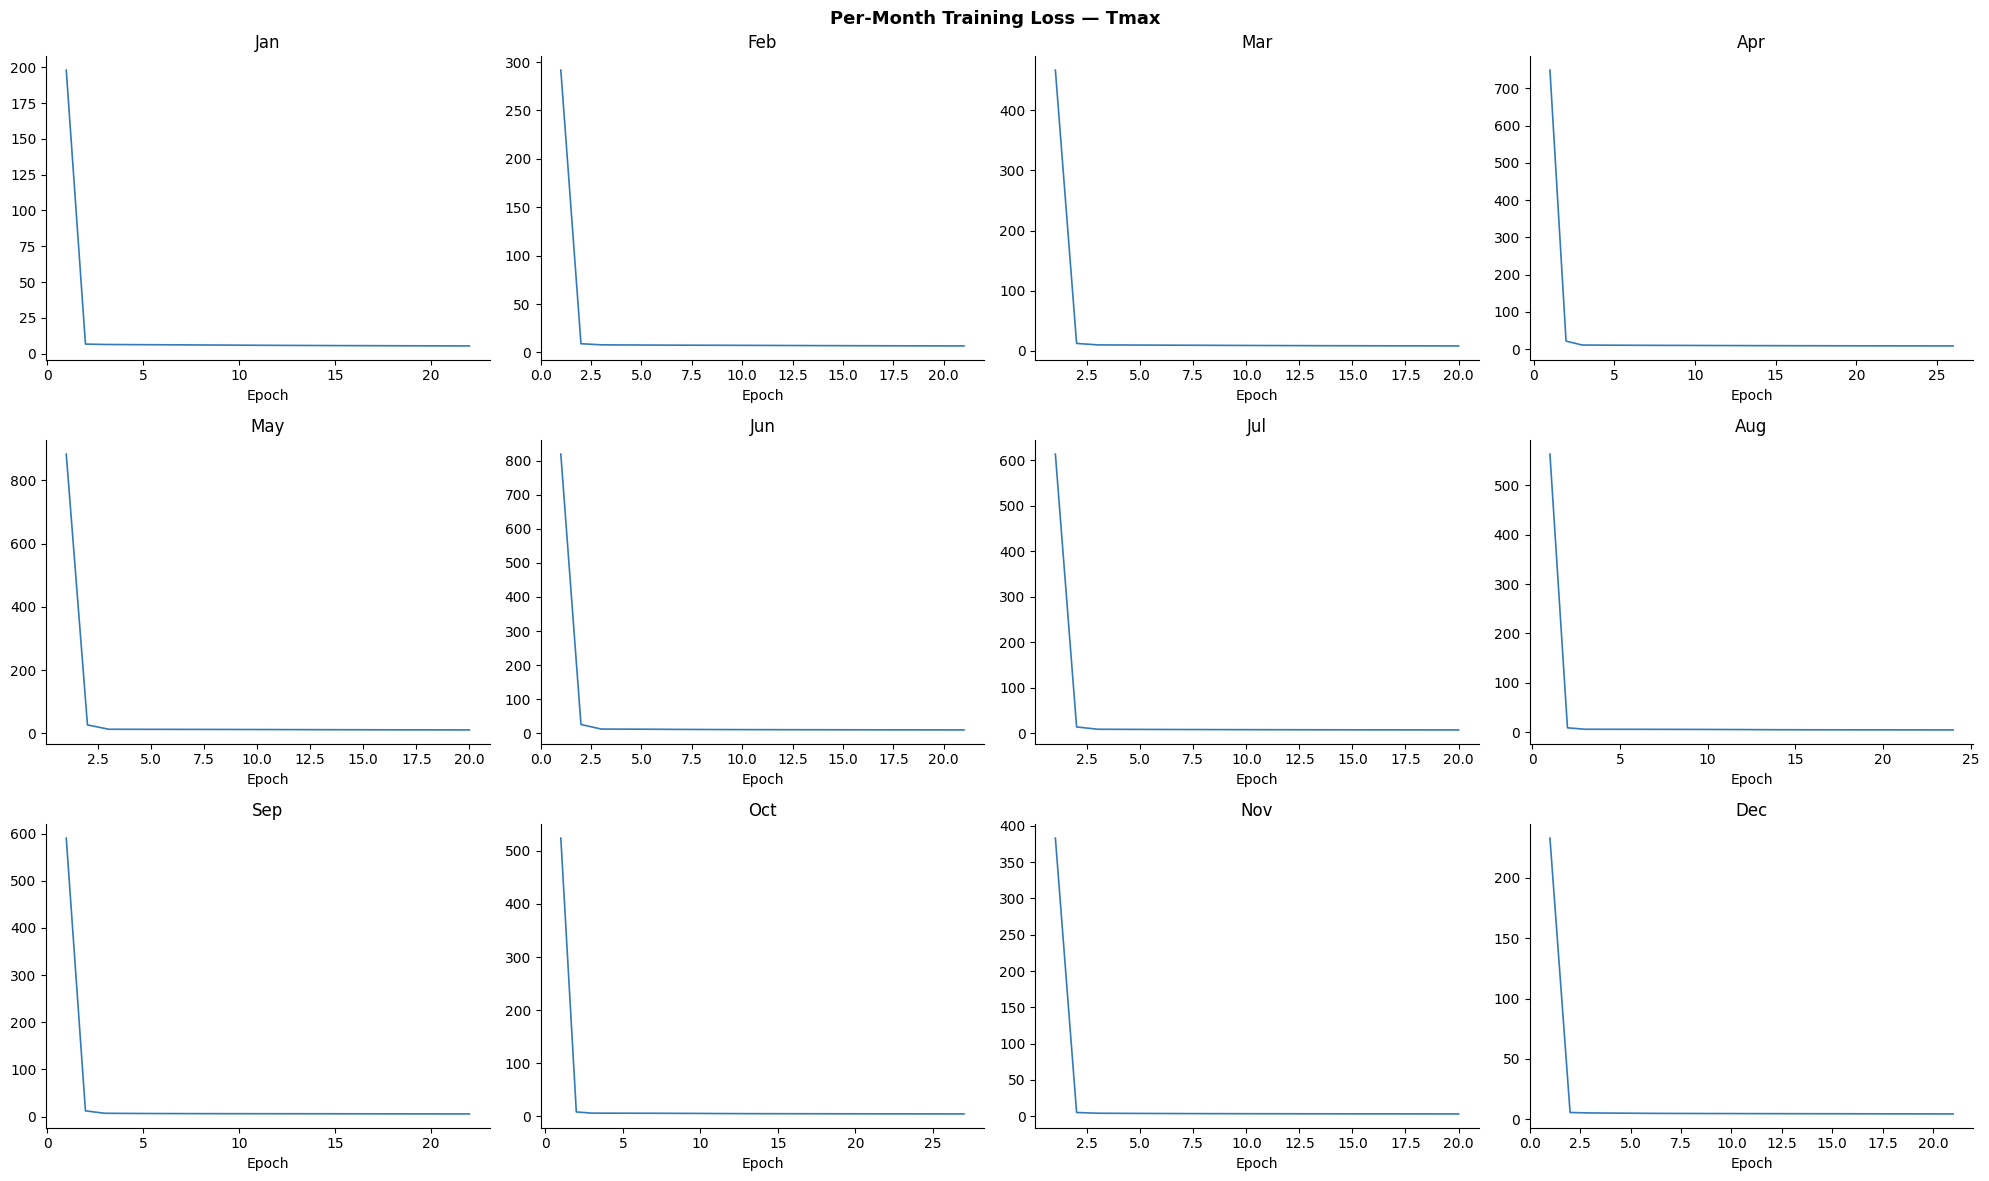

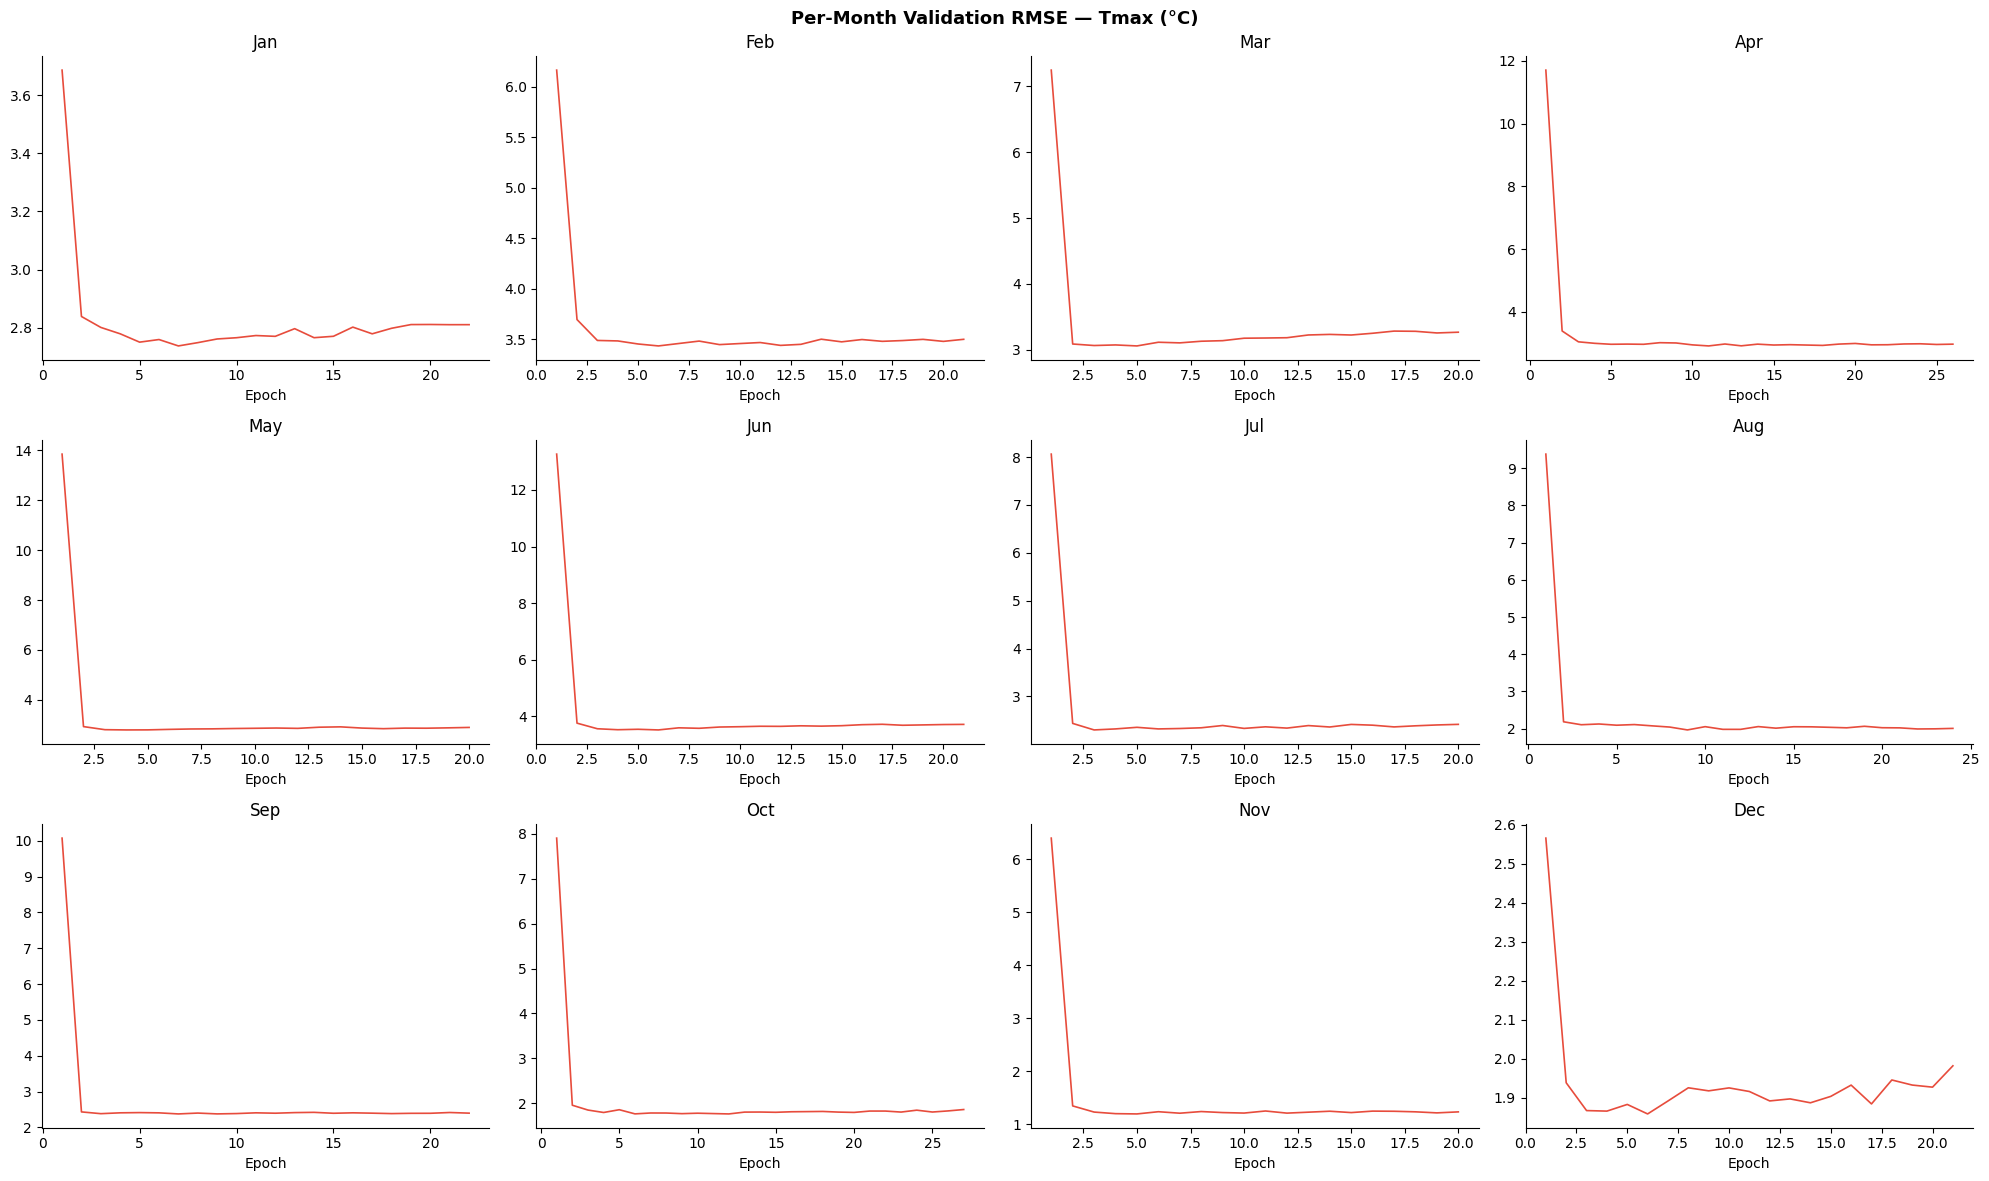

✅ Saved → loss_curves.png, val_rmse_curves.png


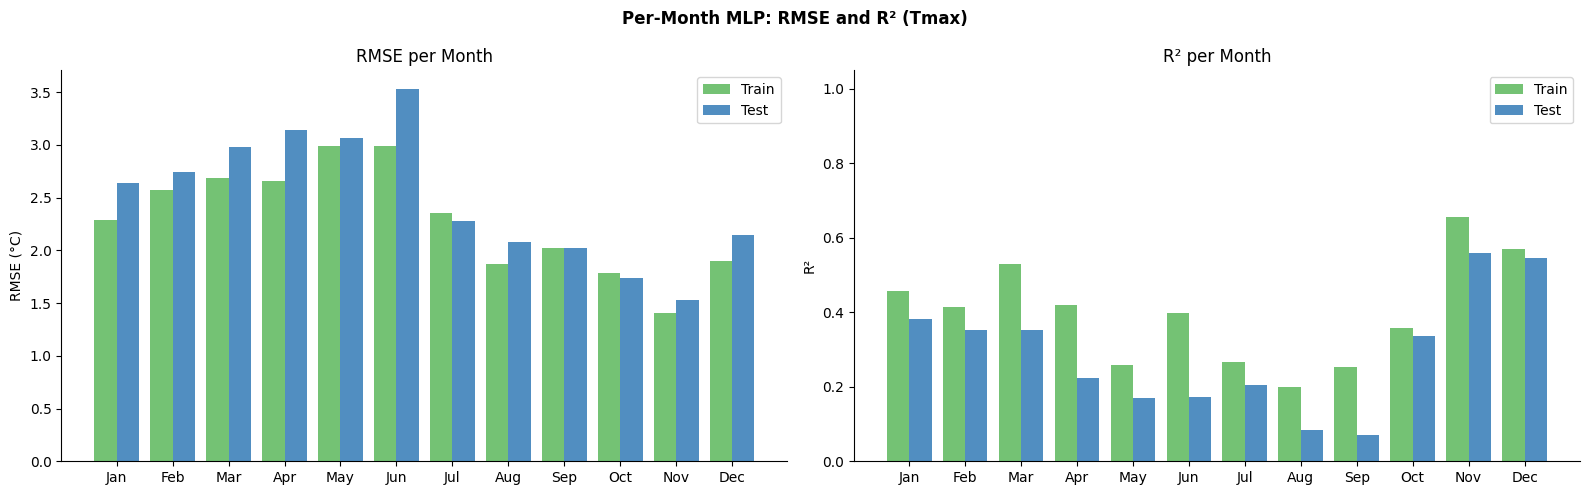

✅ Saved → permonth_metrics.png

✅ All metrics saved → /kaggle/working/tmax_bcsd_output/metrics_revised_tmax.csv
✅ Revised evaluation complete.


In [10]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 6 — DETAILED EVALUATION (low-RAM)                             ║
# ║  IDENTICAL metrics/plots/CSV to chirts_down_bias (comparable).       ║
# ║    • monthly totals → nanMEAN (avg temp, not sum)                   ║
# ║    • no >=0 filter on obs/preds   • units = °C                      ║
# ║  Stages (BCSD order): raw GCM · QM bias-corrected · MLP downscaled.  ║
# ╚══════════════════════════════════════════════════════════════════════╝
import os, gc
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

gc.collect()

# ── reload 1° QM TFs if needed ──────────────────────────────────────────
if "qm1" not in globals() or not qm1:
    if os.path.exists(QM1_TF_PATH):
        with np.load(QM1_TF_PATH) as z:
            qm1 = {k: z[k] for k in z.files}
        print(f"✅ Loaded 1° QM transfer functions for {len(qm1)//2} month(s)")
    else:
        raise FileNotFoundError(f"QM transfer file not found: {QM1_TF_PATH}")

EVAL_YEARS  = range(TEST_START, TEST_END + 1)
EVAL_NC_MLP = MLP_TEST_NC

STAGES = ["raw", "mlp", "bias"]
LABELS = {"raw": "Raw GCM", "mlp": "MLP downscaled", "bias": "QM Bias-corrected"}
COLORS = {"raw": "#bbbbbb", "mlp": "#337ab7", "bias": "#f0ad4e"}

# ── metric helpers ───────────────────────────────────────────────────────
def _rmse_e(o, p): return float(np.sqrt(np.nanmean((o - p) ** 2)))
def _r2_e(o, p):
    ss = np.nansum((o - np.nanmean(o)) ** 2)
    return float(1 - np.nansum((o - p) ** 2) / ss) if ss > 0 else np.nan
def _corr_e(o, p):
    if o.size < 2 or np.nanstd(o) == 0 or np.nanstd(p) == 0: return np.nan
    return float(np.corrcoef(o, p)[0, 1])
def _kge_components_e(o, p):
    if o.size < 2: return np.nan, np.nan, np.nan, np.nan
    r = _corr_e(o, p)
    a = float(np.nanstd(p) / np.nanstd(o)) if np.nanstd(o) > 0 else np.nan
    b = float(np.nanmean(p) / np.nanmean(o)) if np.nanmean(o) != 0 else np.nan
    if any(np.isnan(v) for v in [r, a, b]): return np.nan, r, a, b
    kge = float(1 - np.sqrt((r - 1)**2 + (a - 1)**2 + (b - 1)**2))
    return kge, r, a, b

# ════════════════════════════════════════════════════════════════════════════
#  SINGLE PASS
# ════════════════════════════════════════════════════════════════════════════
print("Computing all metrics in single low-RAM pass …", flush=True)

monthly_rmse   = {s: np.full(12, np.nan) for s in STAGES}
monthly_r2     = {s: np.full(12, np.nan) for s in STAGES}
daily_rmse     = {s: np.full(12, np.nan) for s in STAGES}
daily_r2       = {s: np.full(12, np.nan) for s in STAGES}
clim_sum       = {s: np.zeros(n5)  for s in STAGES}
obs_clim_sum   = np.zeros(n5)
reg_mon_sum    = {s: np.zeros(12) for s in STAGES}
obs_reg_mon_sum = np.zeros(12)
reg_mon_cnt    = np.zeros(12)
total_days     = 0

mon_series     = {s: [] for s in STAGES}
obs_mon_list   = []
daily_reg_series = {s: [] for s in STAGES}
obs_daily_reg    = []

obs_clim_maps  = {}
pred_clim_maps = {s: {} for s in STAGES}

dsm = xr.open_dataset(EVAL_NC_MLP)

for month in range(1, 13):
    g1, doy, dates = load_month("gcm1", list(EVAL_YEARS), month)
    obs            = load_month("chr5", list(EVAL_YEARS), month)[0]
    if g1 is None or obs is None:
        print(f"  {MONTH_NAMES[month-1]}: skip", flush=True); continue

    mk = f"m{month:02d}"
    da_mlp = dsm[VAR_NAME].sel(time=dsm[VAR_NAME].time.dt.month == month)
    n = min(len(g1), len(obs), len(da_mlp.time))

    raw   = bc1_to_005(g1[:n])                                              # raw GCM → 0.05°
    bias  = bc1_to_005(qm_apply(g1[:n], qm1[f"{mk}_obs_q"], qm1[f"{mk}_his_q"]))  # QM-BC 1° → 0.05°
    mlp   = da_mlp.values[:n, WIN5["ii"], WIN5["jj"]]                        # MLP 0.05°
    obs_n = obs[:n]
    yrs   = dates[:n].year.values
    preds = {"raw": raw, "mlp": mlp, "bias": bias}

    obs_v = np.where(np.isfinite(obs_n), obs_n, np.nan)         # ← NO >=0 filter

    # ── DAILY per-cell metrics  (VECTORIZED — identical to per-cell loop) ──
    for s in STAGES:
        p_v = np.where(np.isfinite(preds[s]), preds[s], np.nan) # ← NO >=0 filter
        m_dc = np.isfinite(obs_v) & np.isfinite(p_v)            # joint finite mask (days×cells)
        O = np.where(m_dc, obs_v, np.nan); P = np.where(m_dc, p_v, np.nan)
        keep = m_dc.sum(axis=0) >= 2                            # replicate '<2 skip'
        if keep.any():
            with np.errstate(invalid="ignore", divide="ignore"):
                diff2  = (O - P) ** 2
                rmse_c = np.sqrt(np.nanmean(diff2, axis=0))
                Omean  = np.nanmean(O, axis=0)
                ss_res = np.nansum(diff2, axis=0)
                ss_tot = np.nansum((O - Omean) ** 2, axis=0)
                r2_c   = np.where(ss_tot > 0, 1 - ss_res / ss_tot, np.nan)
            daily_rmse[s][month-1] = float(np.nanmean(rmse_c[keep]))
            daily_r2[s][month-1]   = float(np.nanmean(r2_c[keep]))

    # ── MONTHLY metrics (per-year MEAN → per-cell metric → avg) ──────
    # ★ nanmean instead of nansum (avg temperature, not total)
    uy = np.unique(yrs)
    with np.errstate(invalid="ignore", divide="ignore"):
        oavg = np.stack([np.nanmean(obs_n[yrs == yr], axis=0) for yr in uy])   # (Y, cells)
        for s in STAGES:
            pavg = np.stack([np.nanmean(preds[s][yrs == yr], axis=0) for yr in uy])
            vv   = np.isfinite(oavg) & np.isfinite(pavg)
            OA = np.where(vv, oavg, np.nan); PA = np.where(vv, pavg, np.nan)
            keep = vv.sum(axis=1) > 0                           # replicate 'if vv.sum()==0: continue'
            if keep.any():
                diff2  = (OA - PA) ** 2
                rmse_y = np.sqrt(np.nanmean(diff2, axis=1))
                Omean  = np.nanmean(OA, axis=1, keepdims=True)
                ss_res = np.nansum(diff2, axis=1)
                ss_tot = np.nansum((OA - Omean) ** 2, axis=1)
                r2_y   = np.where(ss_tot > 0, 1 - ss_res / ss_tot, np.nan)
                monthly_rmse[s][month-1] = float(np.nanmean(rmse_y[keep]))
                monthly_r2[s][month-1]   = float(np.nanmean(r2_y[keep]))

    # ── region-mean monthly series (for KGE) ─
    for yr in np.unique(yrs):
        sel = yrs == yr
        obs_mon_list.append(float(np.nanmean(np.nanmean(obs_n[sel], axis=0))))
        for s in STAGES:
            mon_series[s].append(float(np.nanmean(np.nanmean(preds[s][sel], axis=0))))

    # ── region-mean daily series ──
    obs_daily_reg.append(np.nanmean(obs_v, axis=1))
    for s in STAGES:
        daily_reg_series[s].append(np.nanmean(
            np.where(np.isfinite(preds[s]), preds[s], np.nan), axis=1))

    # ── climatology ──
    obs_clim_sum += np.nansum(obs_v, axis=0)
    total_days   += n
    for s in STAGES:
        clim_sum[s] += np.nansum(
            np.where(np.isfinite(preds[s]), preds[s], np.nan), axis=0)

    obs_clim_maps[month] = np.nanmean(obs_v, axis=0)
    for s in STAGES:
        pred_clim_maps[s][month] = np.nanmean(
            np.where(np.isfinite(preds[s]), preds[s], np.nan), axis=0)

    # ── annual cycle ──
    obs_reg_mon_sum[month-1] += float(np.nanmean(obs_v))
    reg_mon_cnt[month-1]     += 1
    for s in STAGES:
        reg_mon_sum[s][month-1] += float(
            np.nanmean(np.where(np.isfinite(preds[s]), preds[s], np.nan)))

    del raw, mlp, bias, obs_n, obs_v, preds, da_mlp
    gc.collect()
    print(f"  {MONTH_NAMES[month-1]} ✓", end="  ", flush=True)

dsm.close(); gc.collect()
print("\n✓ single-pass collection done\n")

# ── derived scalars ──────────────────────────────────────────────────────
obs_clim     = obs_clim_sum / max(total_days, 1)
clim_percell = {s: clim_sum[s] / max(total_days, 1) for s in STAGES}
cnt = np.where(reg_mon_cnt == 0, 1, reg_mon_cnt)
obs_reg_mon  = obs_reg_mon_sum / cnt
reg_mon_mean = {s: reg_mon_sum[s] / cnt for s in STAGES}

obs_mon_arr = np.array(obs_mon_list)
monthly_kge = {}
for s in STAGES:
    kge, r, a, b = _kge_components_e(obs_mon_arr, np.array(mon_series[s]))
    monthly_kge[s] = {"KGE": kge, "r": r, "alpha": a, "beta": b}

valid_months = sorted(obs_clim_maps.keys())
spatial_clim_corr = {}
for s in STAGES:
    p_vec = np.concatenate([pred_clim_maps[s][m] for m in valid_months if m in pred_clim_maps[s]])
    o_vec = np.concatenate([obs_clim_maps[m] for m in valid_months if m in pred_clim_maps[s]])
    v = np.isfinite(o_vec) & np.isfinite(p_vec)
    spatial_clim_corr[s] = _corr_e(o_vec[v], p_vec[v])

annual_cycle_corr = {s: _corr_e(obs_reg_mon, reg_mon_mean[s]) for s in STAGES}

annual_pattern_corr = {}
v_ap = np.isfinite(obs_clim)
for s in STAGES:
    vv = v_ap & np.isfinite(clim_percell[s])
    annual_pattern_corr[s] = _corr_e(obs_clim[vv], clim_percell[s][vv])

# JJAS KGE & R²
jjas_idx = []
k = 0
for month in range(1, 13):
    g1, _, _ = load_month("gcm1", list(EVAL_YEARS), month)
    obs      = load_month("chr5", list(EVAL_YEARS), month)[0]
    if g1 is None or obs is None: continue
    n2 = min(len(g1), len(obs))
    if month in [6, 7, 8, 9]:
        jjas_idx.extend(range(k, k + n2))
    k += n2

jjas_kge, jjas_r2 = {}, {}
for s in STAGES:
    ms = np.array(mon_series[s])
    if not jjas_idx or len(ms) == 0:
        jjas_kge[s] = {"KGE": np.nan, "r": np.nan, "alpha": np.nan, "beta": np.nan}
        jjas_r2[s] = np.nan; continue
    vi = [i for i in jjas_idx if i < len(ms) and i < len(obs_mon_arr)]
    o_j, p_j = obs_mon_arr[vi], ms[vi]
    vm = np.isfinite(o_j) & np.isfinite(p_j)
    kge, r, a, b = _kge_components_e(o_j[vm], p_j[vm])
    jjas_kge[s] = {"KGE": kge, "r": r, "alpha": a, "beta": b}
    jjas_r2[s] = _r2_e(o_j[vm], p_j[vm])

obs_d = np.concatenate(obs_daily_reg)
daily_kge = {}
for s in STAGES:
    pd_arr = np.concatenate(daily_reg_series[s])
    kge, r, a, b = _kge_components_e(obs_d, pd_arr)
    daily_kge[s] = {"KGE": kge, "r": r, "alpha": a, "beta": b}

# ════════════════════════════════════════════════════════════════════════════
# PRINT FULL METRICS TABLE
# ════════════════════════════════════════════════════════════════════════════
yr0, yr1 = EVAL_YEARS.start, EVAL_YEARS.stop - 1
print(f"\n{'='*72}")
print(f"  METRICS TABLE — {VAR_LABEL}  (test {yr0}–{yr1})")
print(f"{'='*72}")

def _fmt(v): return f"{v:8.4f}" if np.isfinite(v) else "     nan"

header = f"{'Metric':<38}" + "".join(f"  {LABELS[s]:>18}" for s in STAGES)
print(header); print("-"*len(header))

print("\n── MONTHLY ──────────────────────────────────────────────────────────")
for m in range(1, 13):
    print(f"  Monthly RMSE {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(monthly_rmse[s][m-1]) for s in STAGES]))
for m in range(1, 13):
    print(f"  Monthly R²   {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(monthly_r2[s][m-1]) for s in STAGES]))
print(f"\n  {'Metric':<38}" + "".join(f"  {LABELS[s]:>18}" for s in STAGES))
print("  " + "-"*78)
for key in ["KGE", "r", "alpha", "beta"]:
    row = [monthly_kge[s][key] for s in STAGES]
    print(f"  Monthly {key:<30}" + "".join([f"  {_fmt(v):>18}" for v in row]))

print("\n── SPATIAL & ANNUAL CYCLE ────────────────────────────────────────────")
print(f"  {'Spatial Climatology Corr (12 maps)':<38}" +
      "".join(f"  {_fmt(spatial_clim_corr[s]):>18}" for s in STAGES))
print(f"  {'Annual Cycle Corr (12-pt region mean)':<38}" +
      "".join(f"  {_fmt(annual_cycle_corr[s]):>18}" for s in STAGES))
print(f"  {'Annual Pattern Corr (per-cell mean)':<38}" +
      "".join(f"  {_fmt(annual_pattern_corr[s]):>18}" for s in STAGES))

print("\n── JJAS ──────────────────────────────────────────────────────────────")
for key in ["KGE", "r", "alpha", "beta"]:
    row = [jjas_kge[s][key] for s in STAGES]
    print(f"  JJAS {key:<33}" + "".join([f"  {_fmt(v):>18}" for v in row]))
print(f"  {'JJAS R² (region-mean series)':<38}" +
      "".join(f"  {_fmt(jjas_r2[s]):>18}" for s in STAGES))

print("\n── DAILY ─────────────────────────────────────────────────────────────")
for m in range(1, 13):
    print(f"  Daily RMSE {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(daily_rmse[s][m-1]) for s in STAGES]))
for m in range(1, 13):
    print(f"  Daily R²   {MONTH_NAMES[m-1]:<4}  (per-cell→avg)  "
          + "  ".join([_fmt(daily_r2[s][m-1]) for s in STAGES]))
for key in ["KGE", "r", "alpha", "beta"]:
    row = [daily_kge[s][key] for s in STAGES]
    print(f"  Daily {key:<33}" + "".join([f"  {_fmt(v):>18}" for v in row]))

# ════════════════════════════════════════════════════════════════════════════
# STAGE BAR CHARTS
# ════════════════════════════════════════════════════════════════════════════
x = np.arange(12); w = 0.27
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle(f"Stage comparison — {VAR_LABEL} per-cell then spatially averaged\n"
             f"(test {yr0}–{yr1})", fontsize=14, fontweight="bold")

ax = axes[0, 0]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, monthly_rmse[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Monthly RMSE (per-cell → spatial avg)"); ax.set_ylabel(f"RMSE ({UNITS})")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

ax = axes[0, 1]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, monthly_r2[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Monthly R² (per-cell → spatial avg)"); ax.set_ylabel("R²")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

ax = axes[1, 0]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, daily_rmse[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Daily RMSE (per-cell → spatial avg)"); ax.set_ylabel(f"RMSE ({UNITS})")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

ax = axes[1, 1]
for i, s in enumerate(STAGES):
    ax.bar(x + (i-1)*w, daily_r2[s], w, label=LABELS[s], color=COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_title("Daily R² (per-cell → spatial avg)"); ax.set_ylabel("R²")
ax.legend(); ax.spines[["top","right"]].set_visible(False); ax.axhline(0, color="k", lw=.6)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/stage_bars_percell_avg.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → stage_bars_percell_avg.png")

# ════════════════════════════════════════════════════════════════════════════
# ANNUAL CYCLE LINE PLOT
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, 13), obs_reg_mon, "k-o", lw=2, label="CHIRTS obs")
for s in STAGES:
    ax.plot(range(1, 13), reg_mon_mean[s], "--", color=COLORS[s], label=LABELS[s])
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel(f"mean {UNITS}"); ax.set_title(f"Annual Cycle — {VAR_LABEL} region-mean (12-pt)")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/annual_cycle.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → annual_cycle.png")

# ════════════════════════════════════════════════════════════════════════════
# KGE DECOMPOSITION
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"KGE Decomposition — {VAR_LABEL} region-mean series", fontsize=13, fontweight="bold")
kge_sets = [("Monthly KGE", monthly_kge), ("JJAS KGE", jjas_kge), ("Daily KGE", daily_kge)]
comp_labels = {"r": "Correlation r", "alpha": "Variability α", "beta": "Bias β"}
comp_colors = {"r": "#337ab7", "alpha": "#f0ad4e", "beta": "#5cb85c"}

for ax, (title, kge_dict) in zip(axes, kge_sets):
    xs = np.arange(len(STAGES)); bw = 0.25
    for j, comp in enumerate(["r", "alpha", "beta"]):
        vals = [kge_dict[s][comp] for s in STAGES]
        ax.bar(xs + (j-1)*bw, vals, bw, label=comp_labels[comp], color=comp_colors[comp])
    ax.axhline(1, color="k", lw=0.8, ls="--", label="ideal=1")
    ax.axhline(0, color="k", lw=0.4)
    ax.set_xticks(xs); ax.set_xticklabels([LABELS[s] for s in STAGES], fontsize=8, rotation=10)
    ax.set_title(title); ax.legend(fontsize=7)
    ax.spines[["top","right"]].set_visible(False)
    for j2, s in enumerate(STAGES):
        kge_v = kge_dict[s]["KGE"]
        ax.text(j2, ax.get_ylim()[0]*0.97 if ax.get_ylim()[0] < 0 else -0.05,
                f"KGE={kge_v:.3f}", ha="center", fontsize=7, color="black")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/kge_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → kge_decomposition.png")

# ════════════════════════════════════════════════════════════════════════════
# TRAINING CURVES
# ════════════════════════════════════════════════════════════════════════════
if "epoch_metrics" not in globals() or not epoch_metrics:
    epoch_metrics = {}
    for month in range(1, 13):
        mstr = f"m{month:02d}"
        ep_csv = os.path.join(OUT_DIR, f"epoch_{mstr}.csv")
        if os.path.exists(ep_csv):
            d = pd.read_csv(ep_csv)
            epoch_metrics[month] = {
                "loss":     d["loss"].tolist() if "loss" in d else [],
                "val_rmse": d["val_rmse"].dropna().tolist() if "val_rmse" in d else [],
            }
    if epoch_metrics:
        print(f"✅ Loaded epoch metrics from CSV for {len(epoch_metrics)} month(s)")

if epoch_metrics:
    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes_flat = axes.ravel()
    fig.suptitle(f"Per-Month Training Loss — {VAR_LABEL}", fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes_flat[m-1]
        key = "loss" if (m in epoch_metrics and epoch_metrics[m].get("loss")) else "train_loss"
        if m in epoch_metrics and epoch_metrics[m].get(key):
            vals = epoch_metrics[m][key]
            ax.plot(range(1, len(vals)+1), vals, color="#337ab7", lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("Epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/loss_curves.png", dpi=150, bbox_inches="tight"); plt.show()

    fig, axes = plt.subplots(3, 4, figsize=(20, 12)); axes_flat = axes.ravel()
    fig.suptitle(f"Per-Month Validation RMSE — {VAR_LABEL} ({UNITS})", fontsize=13, fontweight="bold")
    for m in range(1, 13):
        ax = axes_flat[m-1]
        if m in epoch_metrics and epoch_metrics[m].get("val_rmse"):
            vals = epoch_metrics[m]["val_rmse"]
            ax.plot(range(1, len(vals)+1), vals, color="#e74c3c", lw=1.2)
        ax.set_title(MONTH_NAMES[m-1]); ax.set_xlabel("Epoch")
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/val_rmse_curves.png", dpi=150, bbox_inches="tight"); plt.show()
    print("✅ Saved → loss_curves.png, val_rmse_curves.png")

    if "summary" in globals() and summary:
        months = [m for m in range(1, 13) if m in summary]
        if months:
            x2, w2 = np.arange(len(months)), 0.4
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
            fig.suptitle(f"Per-Month MLP: RMSE and R² ({VAR_LABEL})", fontsize=12, fontweight="bold")
            for ax, i_tr, i_te, ylab, ttl, ylim in [
                (ax1, 0, 2, f"RMSE ({UNITS})", "RMSE per Month", None),
                (ax2, 1, 3, "R²",              "R² per Month",   (0, 1.05))]:
                ax.bar(x2-w2/2, [summary[m][i_tr] for m in months], w2,
                       label="Train", color="#5cb85c", alpha=.85)
                ax.bar(x2+w2/2, [summary[m][i_te] for m in months], w2,
                       label="Test",  color="#337ab7", alpha=.85)
                ax.set_xticks(x2); ax.set_xticklabels([MONTH_NAMES[m-1] for m in months])
                ax.set_ylabel(ylab); ax.set_title(ttl)
                if ylim: ax.set_ylim(*ylim)
                ax.legend(); ax.spines[["top","right"]].set_visible(False)
            plt.tight_layout()
            plt.savefig(f"{OUT_DIR}/permonth_metrics.png", dpi=150, bbox_inches="tight"); plt.show()
            print("✅ Saved → permonth_metrics.png")
else:
    print("ℹ No epoch metrics found — skipping training curves")

# ════════════════════════════════════════════════════════════════════════════
# SAVE METRICS TO CSV
# ════════════════════════════════════════════════════════════════════════════
rows = []
for m in range(1, 13):
    rows.append({"metric": f"Monthly RMSE {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: monthly_rmse[s][m-1] for s in STAGES}})
for m in range(1, 13):
    rows.append({"metric": f"Monthly R² {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: monthly_r2[s][m-1] for s in STAGES}})
for key in ["KGE", "r", "alpha", "beta"]:
    rows.append({"metric": f"Monthly {key} (region-mean series)", "method": "region-mean",
                 **{LABELS[s]: monthly_kge[s][key] for s in STAGES}})
rows.append({"metric": "Spatial Climatology Corr (12 maps concat)", "method": "per-cell spatial",
             **{LABELS[s]: spatial_clim_corr[s] for s in STAGES}})
rows.append({"metric": "Annual Cycle Corr (12-pt region mean)", "method": "region-mean",
             **{LABELS[s]: annual_cycle_corr[s] for s in STAGES}})
rows.append({"metric": "Annual Pattern Corr (per-cell annual mean)", "method": "per-cell spatial",
             **{LABELS[s]: annual_pattern_corr[s] for s in STAGES}})
for key in ["KGE", "r", "alpha", "beta"]:
    rows.append({"metric": f"JJAS {key} (region-mean series)", "method": "region-mean",
                 **{LABELS[s]: jjas_kge[s][key] for s in STAGES}})
rows.append({"metric": "JJAS R² (region-mean JJAS series)", "method": "region-mean",
             **{LABELS[s]: jjas_r2[s] for s in STAGES}})
for m in range(1, 13):
    rows.append({"metric": f"Daily RMSE {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: daily_rmse[s][m-1] for s in STAGES}})
for m in range(1, 13):
    rows.append({"metric": f"Daily R² {MONTH_NAMES[m-1]} (per-cell→avg)", "method": "per-cell→spatial avg",
                 **{LABELS[s]: daily_r2[s][m-1] for s in STAGES}})
for key in ["KGE", "r", "alpha", "beta"]:
    rows.append({"metric": f"Daily {key} (region-mean daily series)", "method": "region-mean",
                 **{LABELS[s]: daily_kge[s][key] for s in STAGES}})

df_metrics = pd.DataFrame(rows)
out_csv = f"{OUT_DIR}/metrics_revised_tmax.csv"
df_metrics.to_csv(out_csv, index=False)
print(f"\n✅ All metrics saved → {out_csv}")
print("✅ Revised evaluation complete.")

In [11]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 7 — Zip everything for download                               ║
# ╚══════════════════════════════════════════════════════════════════════╝
import shutil
zip_path = shutil.make_archive("/kaggle/working/tmax_bcsd_results", "zip", OUT_DIR)
print(f"✅ {zip_path}  ({os.path.getsize(zip_path)/1e6:.1f} MB)")
print("Download from the notebook's Output panel →")
print("\nTo resume on next kernel restart:")
print("  1. Download this zip from the Output panel")
print("  2. Extract and upload the tmax_bcsd_output/ folder")
print("     back into your Kaggle dataset")
print("  3. On next run, QM + trained months + Optuna will be auto-restored")

✅ /kaggle/working/tmax_bcsd_results.zip  (176.5 MB)
Download from the notebook's Output panel →

To resume on next kernel restart:
  1. Download this zip from the Output panel
  2. Extract and upload the tmax_bcsd_output/ folder
     back into your Kaggle dataset
  3. On next run, QM + trained months + Optuna will be auto-restored
